# Классификация видов птиц по аудиозаписям с помощью нейронной сети

В этом проекте решается задача автоматического распознавания вида птицы по короткому аудиофрагменту. Исходные аудиозаписи преобразуются в Mel-спектрограммы, после чего по ним обучается сверточная нейронная сеть (CNN).

 В отличие от классических задач распознавания речи, биоакустические данные характеризуются высокой внутриклассовой вариативностью (индивидуальные различия особей, географические диалекты, возрастные и сезонные вариации вокализации), значительным уровнем фонового шума (антропогенного и природного происхождения), а также перекрытием частотных диапазонов между видами. Дополнительную сложность создаёт неравномерная представленность видов в открытых краудсорсинговых корпусах и систематическое смещение географического распределения записей.


**Цель проекта** — построить и сравнить несколько подходов к автоматической идентификации вида по короткому акустическому фрагменту, оценить применимость предобученных специализированных моделей в режиме zero-shot и после доменоспецифичного fine-tuning, а также исследовать влияние акустической различимости классов на качество классификации путём контролируемого изменения состава выборки.


**Описание данных:**
Данные были собраны через API Xeno-canto — краудсорсинговой базы аудиозаписей птиц. Были получены метаданные записей о птицах, по которым затем из базы данных выгружались аудиозаписи. В итоговом датасете суммарно содержалось 2973 аудиофайлов. Каждая запись нарезалась на 5-секундные сегменты с ограничением в 5 сегментов на файл.


**Использованные методы**:
- Audio ML: работа с датасетом аудиозаписей проекта `xeno-canto`, построение сверточной сети из четырех блоков на Mel-спектрограммах (в двух вариантах: без аугментации и с SpecAugment)
- Fine-Tuning: использование предобученной нейросети BirdNet на наших данных в двух режимах: zero-shot (в базовой настройке, без дообучения) и fine-tuned (дообученние на наших классах)



В проекте рассматриваются три основных результата:

1. классификация 15 видов птиц с помощью CNN + SpecAugment;
2. дополнительный эксперимент на 10 классах;
3. сравнение с BirdNET zero-shot baseline.

**Ключевой результат:** на выбранной тестовой выборке CNN + SpecAugment получила `accuracy ≈ 0.456` и `macro-F1 ≈ 0.456` на 15 классах. При уменьшении числа классов до 10 качество выросло до `accuracy ≈ 0.560` и `macro-F1 ≈ 0.558`.
⭕️результаты дообучения

In [59]:
import random
import json
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Выбор видов птиц

Для проекта были выбраны 15 видов птиц, распространённых в России и Европе. В список вошли певчие птицы, городские виды, водоплавающие и околоводные птицы, дятел и хищная птица.

In [2]:
species = {
    "parus_major": {
        "ru": "Большая синица",
        "en": "Great Tit",
        "scientific": "Parus major"
    },
    "fringilla_coelebs": {
        "ru": "Зяблик",
        "en": "Common Chaffinch",
        "scientific": "Fringilla coelebs"
    },
    "turdus_merula": {
        "ru": "Чёрный дрозд",
        "en": "Eurasian Blackbird",
        "scientific": "Turdus merula"
    },
    "erithacus_rubecula": {
        "ru": "Зарянка",
        "en": "European Robin",
        "scientific": "Erithacus rubecula"
    },
    "dendrocopos_major": {
        "ru": "Большой пёстрый дятел",
        "en": "Great Spotted Woodpecker",
        "scientific": "Dendrocopos major"
    },
    "motacilla_alba": {
        "ru": "Белая трясогузка",
        "en": "White Wagtail",
        "scientific": "Motacilla alba"
    },
    "anas_platyrhynchos": {
        "ru": "Кряква",
        "en": "Mallard",
        "scientific": "Anas platyrhynchos"
    },
    "chroicocephalus_ridibundus": {
        "ru": "Озёрная чайка",
        "en": "Black-headed Gull",
        "scientific": "Chroicocephalus ridibundus"
    },
    "cuculus_canorus": {
        "ru": "Обыкновенная кукушка",
        "en": "Common Cuckoo",
        "scientific": "Cuculus canorus"
    },
    "falco_tinnunculus": {
        "ru": "Обыкновенная пустельга",
        "en": "Common Kestrel",
        "scientific": "Falco tinnunculus"
    },
}

new_species = {
    "columba_livia": {
        "ru": "Сизый голубь",
        "en": "Rock Dove / Feral Pigeon",
        "scientific": "Columba livia"
    },
    "corvus_cornix": {
        "ru": "Серая ворона",
        "en": "Hooded Crow",
        "scientific": "Corvus cornix"
    },
    "pica_pica": {
        "ru": "Сорока",
        "en": "Eurasian Magpie",
        "scientific": "Pica pica"
    },
    "sturnus_vulgaris": {
        "ru": "Обыкновенный скворец",
        "en": "Common Starling",
        "scientific": "Sturnus vulgaris"
    },
    "apus_apus": {
        "ru": "Чёрный стриж",
        "en": "Common Swift",
        "scientific": "Apus apus"
    },
}

species.update(new_species)

### Подключение к Xeno-canto API

Для загрузки метаданных и аудиозаписей используется Xeno-canto API.

In [1]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/birdvoice_project")

XC_DIR = PROJECT_DIR / "data" / "raw" / "xeno_canto"
META_DIR = XC_DIR / "metadata"
AUDIO_DIR = XC_DIR / "audio"

META_DIR.mkdir(parents=True, exist_ok=True)
AUDIO_DIR.mkdir(parents=True, exist_ok=True)

print("Project dir:", PROJECT_DIR)
print("Metadata dir:", META_DIR)
print("Audio dir:", AUDIO_DIR)

Project dir: /content/drive/MyDrive/birdvoice_project
Metadata dir: /content/drive/MyDrive/birdvoice_project/data/raw/xeno_canto/metadata
Audio dir: /content/drive/MyDrive/birdvoice_project/data/raw/xeno_canto/audio


In [3]:
from getpass import getpass

XC_API_KEY = getpass("Enter Xeno-canto API key: ")

Enter Xeno-canto API key: ··········


 Прописываем базовый запрос к Xeno-canto API с постраничной прокруткой (API отдаёт максимум одну страницу за раз + дедупликация записей по id)

In [4]:
import requests
import pandas as pd
from time import sleep

def fetch_xc_query(query, api_key, max_pages=20):
    all_records = []

    for page in range(1, max_pages + 1):
        url = "https://xeno-canto.org/api/3/recordings"

        params = {
            "query": query,
            "page": page,
            "key": api_key
        }

        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()

        data = response.json()
        records = data.get("recordings", [])
        all_records.extend(records)

        num_pages = int(data.get("numPages", 1))

        if page >= num_pages:
            break

        sleep(0.5)

    df = pd.DataFrame(all_records)

    if len(df) > 0 and "id" in df.columns:
        df = df.drop_duplicates(subset=["id"])

    return df

### Загрузка метаданных Xeno-canto

На этом этапе для каждого выбранного вида запрашиваются записи качества A и B из базы Xeno-canto. Из выборки исключаются записи, сделанные в России, так как в рамках текущей версии проекта модель обучается только на нероссийских записях.

In [5]:
def fetch_species_non_russia(scientific_name, api_key, max_pages=20):
    genus, species_epithet = scientific_name.split(" ", 1)

    all_dfs = []

    for quality in ["A", "B"]:
        query = f"gen:{genus} sp:{species_epithet} q:{quality}"

        print("Query:", query)

        df = fetch_xc_query(
            query=query,
            api_key=api_key,
            max_pages=max_pages
        )

        if len(df) > 0:
            df["query_quality"] = quality
            all_dfs.append(df)

    if not all_dfs:
        return pd.DataFrame()

    result = pd.concat(all_dfs, ignore_index=True)

    if "id" in result.columns:
        result = result.drop_duplicates(subset=["id"])

    # Убираем Россию
    if "cnt" in result.columns:
        result = result[
            result["cnt"].fillna("").str.lower() != "russia"
        ].copy()
    else:
        print("Warning: no 'cnt' column found, Russia was not filtered")

    return result.reset_index(drop=True)

In [6]:
all_metadata = []

for label, info in species.items():
    print("Fetching:", info["ru"], "|", info["scientific"])

    df = fetch_species_non_russia(
        scientific_name=info["scientific"],
        api_key=XC_API_KEY,
        max_pages=20
    )

    if len(df) == 0:
        print("No records found:", label)
        continue

    df["label"] = label
    df["ru_name"] = info["ru"]
    df["en_name"] = info["en"]
    df["scientific_name"] = info["scientific"]

    print("Found non-Russia records:", len(df))

    df.to_csv(META_DIR / f"{label}_non_russia_metadata.csv", index=False)
    all_metadata.append(df)

metadata_non_russia = pd.concat(all_metadata, ignore_index=True)

metadata_non_russia.to_csv(
    META_DIR / "xeno_canto_10birds_non_russia_full_metadata.csv",
    index=False
)

print("Total records:", len(metadata_non_russia))

Fetching: Большая синица | Parus major
Query: gen:Parus sp:major q:A
Query: gen:Parus sp:major q:B
Found non-Russia records: 2978
Fetching: Зяблик | Fringilla coelebs
Query: gen:Fringilla sp:coelebs q:A
Query: gen:Fringilla sp:coelebs q:B
Found non-Russia records: 2965
Fetching: Чёрный дрозд | Turdus merula
Query: gen:Turdus sp:merula q:A
Query: gen:Turdus sp:merula q:B
Found non-Russia records: 3534
Fetching: Зарянка | Erithacus rubecula
Query: gen:Erithacus sp:rubecula q:A
Query: gen:Erithacus sp:rubecula q:B
Found non-Russia records: 3053
Fetching: Большой пёстрый дятел | Dendrocopos major
Query: gen:Dendrocopos sp:major q:A
Query: gen:Dendrocopos sp:major q:B
Found non-Russia records: 2483
Fetching: Белая трясогузка | Motacilla alba
Query: gen:Motacilla sp:alba q:A
Query: gen:Motacilla sp:alba q:B
Found non-Russia records: 1177
Fetching: Кряква | Anas platyrhynchos
Query: gen:Anas sp:platyrhynchos q:A
Query: gen:Anas sp:platyrhynchos q:B
Found non-Russia records: 961
Fetching: Озёр

In [7]:
new_metadata = []

for label, info in new_species.items():
    print("Fetching:", info["ru"], "|", info["scientific"])

    df = fetch_species_non_russia(
        scientific_name=info["scientific"],
        api_key=XC_API_KEY,
        max_pages=20
    )

    if len(df) == 0:
        print("No records found:", label)
        continue

    df["label"] = label
    df["ru_name"] = info["ru"]
    df["en_name"] = info["en"]
    df["scientific_name"] = info["scientific"]

    print("Found non-Russia records:", len(df))

    df.to_csv(META_DIR / f"{label}_non_russia_metadata.csv", index=False)
    new_metadata.append(df)

new_metadata = pd.concat(new_metadata, ignore_index=True)

Fetching: Сизый голубь | Columba livia
Query: gen:Columba sp:livia q:A
Query: gen:Columba sp:livia q:B
Found non-Russia records: 174
Fetching: Серая ворона | Corvus cornix
Query: gen:Corvus sp:cornix q:A
Query: gen:Corvus sp:cornix q:B
Found non-Russia records: 2820
Fetching: Сорока | Pica pica
Query: gen:Pica sp:pica q:A
Query: gen:Pica sp:pica q:B
Found non-Russia records: 1097
Fetching: Обыкновенный скворец | Sturnus vulgaris
Query: gen:Sturnus sp:vulgaris q:A
Query: gen:Sturnus sp:vulgaris q:B
Found non-Russia records: 1352
Fetching: Чёрный стриж | Apus apus
Query: gen:Apus sp:apus q:A
Query: gen:Apus sp:apus q:B
Found non-Russia records: 627


In [8]:
metadata_15_non_russia = pd.concat(
    [metadata_non_russia, new_metadata],
    ignore_index=True
)

metadata_15_non_russia = metadata_15_non_russia.drop_duplicates(subset=["id"])

metadata_15_non_russia.to_csv(
    META_DIR / "xeno_canto_15birds_non_russia_full_metadata.csv",
    index=False
)

counts_15 = (
    metadata_15_non_russia
    .groupby(["label", "ru_name", "en_name", "scientific_name"])
    .size()
    .reset_index(name="n_records")
    .sort_values("n_records", ascending=False)
)

counts_15

,label,ru_name,en_name,scientific_name,n_records
14,turdus_merula,Чёрный дрозд,Eurasian Blackbird,Turdus merula,3534
7,erithacus_rubecula,Зарянка,European Robin,Erithacus rubecula,3053
11,parus_major,Большая синица,Great Tit,Parus major,2978
9,fringilla_coelebs,Зяблик,Common Chaffinch,Fringilla coelebs,2965
4,corvus_cornix,Серая ворона,Hooded Crow,Corvus cornix,2820
6,dendrocopos_major,Большой пёстрый дятел,Great Spotted Woodpecker,Dendrocopos major,2483
5,cuculus_canorus,Обыкновенная кукушка,Common Cuckoo,Cuculus canorus,1441
13,sturnus_vulgaris,Обыкновенный скворец,Common Starling,Sturnus vulgaris,1352
10,motacilla_alba,Белая трясогузка,White Wagtail,Motacilla alba,1177
12,pica_pica,Сорока,Eurasian Magpie,Pica pica,1097


Итоговая таблица содержит данные по всем 15 видам птичек.

Данные очень несбалансированы: у певчих птиц тысячи записей, у голубя — всего 174. Это проблема, которую мы решим на следующем шаге подвыборкой.

### Формирование финального датасета

Так как количество записей по видам различается, для большинства классов отбирается до 200 записей. Для сизого голубя используется меньше записей, поскольку для него было найдено 174 подходящих аудио. Такой подход позволяет сохранить близкий баланс классов и не увеличивать размер датасета слишком сильно.

In [9]:
N_PER_CLASS = 200
PIGEON_LABEL = "columba_livia"

metadata_final = (
    metadata_15_non_russia
    .groupby("label", group_keys=False)
    .apply(
        lambda x: x if x.name == PIGEON_LABEL
        else x.sample(min(len(x), N_PER_CLASS), random_state=42)
    )
    .reset_index(drop=True)
)

metadata_final["label"].value_counts()

/tmp/ipykernel_6134/3906941503.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,count
label,
anas_platyrhynchos,200
apus_apus,200
chroicocephalus_ridibundus,200
corvus_cornix,200
cuculus_canorus,200
dendrocopos_major,200
erithacus_rubecula,200
parus_major,200
falco_tinnunculus,200


In [10]:
metadata_final.to_csv(
    META_DIR / "xeno_canto_15birds_non_russia_final_metadata.csv",
    index=False
)

final_counts = (
    metadata_final
    .groupby(["label", "ru_name", "en_name", "scientific_name"])
    .size()
    .reset_index(name="n_records")
    .sort_values("n_records", ascending=False)
)

final_counts.to_csv(
    META_DIR / "xeno_canto_15birds_final_counts.csv",
    index=False
)

final_counts

,label,ru_name,en_name,scientific_name,n_records
0,anas_platyrhynchos,Кряква,Mallard,Anas platyrhynchos,200
1,apus_apus,Чёрный стриж,Common Swift,Apus apus,200
2,chroicocephalus_ridibundus,Озёрная чайка,Black-headed Gull,Chroicocephalus ridibundus,200
4,corvus_cornix,Серая ворона,Hooded Crow,Corvus cornix,200
5,cuculus_canorus,Обыкновенная кукушка,Common Cuckoo,Cuculus canorus,200
6,dendrocopos_major,Большой пёстрый дятел,Great Spotted Woodpecker,Dendrocopos major,200
7,erithacus_rubecula,Зарянка,European Robin,Erithacus rubecula,200
11,parus_major,Большая синица,Great Tit,Parus major,200
8,falco_tinnunculus,Обыкновенная пустельга,Common Kestrel,Falco tinnunculus,200
9,fringilla_coelebs,Зяблик,Common Chaffinch,Fringilla coelebs,200


В 14 класах по 200 записей, голубь — 174. Итого - 2974 файла. Подвыборка случайная с `random_state=42`, что обеспечивает воспроизводимость.

### Скачивание аудиофайлов

На этом этапе по сохранённым метаданным скачиваются аудиофайлы выбранных записей. Файлы сохраняются на Google Drive в папки по классам, чтобы дальше их можно было использовать для предобработки и обучения модели.

In [11]:
from tqdm import tqdm
import requests
from time import sleep
from pathlib import Path
import pandas as pd

def download_recordings(metadata, audio_dir):
    downloaded_rows = []

    for label, group in metadata.groupby("label"):
        label_dir = audio_dir / label
        label_dir.mkdir(parents=True, exist_ok=True)

        for _, row in tqdm(group.iterrows(), total=len(group), desc=label):
            xc_id = str(row["id"])
            download_url = f"https://xeno-canto.org/{xc_id}/download"

            ext = "mp3"
            if "file-name" in row and isinstance(row["file-name"], str):
                if "." in row["file-name"]:
                    ext = row["file-name"].split(".")[-1].lower()

            out_path = label_dir / f"XC{xc_id}.{ext}"

            if out_path.exists():
                row_dict = row.to_dict()
                row_dict["local_path"] = str(out_path)
                downloaded_rows.append(row_dict)
                continue

            try:
                r = requests.get(download_url, timeout=60)
                r.raise_for_status()

                with open(out_path, "wb") as f:
                    f.write(r.content)

                row_dict = row.to_dict()
                row_dict["local_path"] = str(out_path)
                downloaded_rows.append(row_dict)

                sleep(0.5)

            except Exception as e:
                print("Failed:", xc_id, e)

    return pd.DataFrame(downloaded_rows)

In [12]:
downloaded_metadata = download_recordings(
    metadata=metadata_final,
    audio_dir=AUDIO_DIR
)

downloaded_metadata.to_csv(
    META_DIR / "xeno_canto_15birds_non_russia_downloaded_metadata.csv",
    index=False
)

downloaded_metadata["label"].value_counts()

turdus_merula: 100%|██████████| 200/200 [08:43<00:00,  2.62s/it]


,count
label,
anas_platyrhynchos,200
apus_apus,200
chroicocephalus_ridibundus,200
corvus_cornix,200
cuculus_canorus,200
dendrocopos_major,200
erithacus_rubecula,200
parus_major,200
falco_tinnunculus,200


Везде, кроме голубей, получилось 200 записей


In [13]:
downloaded_metadata.to_csv(
    META_DIR / "xeno_canto_15birds_non_russia_downloaded_metadata.csv",
    index=False
)

In [14]:
PROJECT_DIR = Path("/content/drive/MyDrive/birdvoice_project")

META_DIR = PROJECT_DIR / "data" / "raw" / "xeno_canto" / "metadata"
SPLITS_DIR = PROJECT_DIR / "data" / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

downloaded_metadata = pd.read_csv(
    META_DIR / "xeno_canto_15birds_non_russia_downloaded_metadata.csv"
)

downloaded_metadata.head()

,id,gen,sp,ssp,grp,en,rec,cnt,loc,lat,...,dvc,mic,smp,annotation-set,query_quality,label,ru_name,en_name,scientific_name,local_path
0,878872,Anas,platyrhynchos,NaN,birds,Mallard,Johannes Dag Mayer,Germany,"Aichtal, Stuttgart, Baden-Württemberg",48.6327,...,AudioMoth 1.2.0,AudioMoth 1.2.0,48000,[],B,anas_platyrhynchos,Кряква,Mallard,Anas platyrhynchos,/content/drive/MyDrive/birdvoice_project/data/...
1,834948,Anas,platyrhynchos,NaN,birds,Mallard,Albert Lastukhin,Russian Federation,"Tonya Avangardnaya, Kamyzyaksky District, Astr...",45.6850,...,NaN,NaN,44100,[],B,anas_platyrhynchos,Кряква,Mallard,Anas platyrhynchos,/content/drive/MyDrive/birdvoice_project/data/...
2,862999,Anas,platyrhynchos,NaN,birds,Mallard,Manuel Grosselet,France,"Jardin Lecoq, Clermont-Ferrand, Puy-de-Dôme, A...",45.7724,...,tascam dr05,dodotronic,44100,[],B,anas_platyrhynchos,Кряква,Mallard,Anas platyrhynchos,/content/drive/MyDrive/birdvoice_project/data/...
3,460903,Anas,platyrhynchos,NaN,birds,Mallard,Nelson Conceição,Portugal,"Conceição de Tavira, Tavira, Faro",37.1905,...,NaN,NaN,48000,[],B,anas_platyrhynchos,Кряква,Mallard,Anas platyrhynchos,/content/drive/MyDrive/birdvoice_project/data/...
4,982946,Anas,platyrhynchos,NaN,birds,Mallard,Nelson Conceição,Portugal,"Luz, Tavira, Faro",37.0689,...,Zoom H1n,Built-in,48000,[],B,anas_platyrhynchos,Кряква,Mallard,Anas platyrhynchos,/content/drive/MyDrive/birdvoice_project/data/...


В итоговой csv-таблице все 15 классов загружены (columba_livia — 174, остальные — 200).
Метаданные сохранены на Drive в порядке защиты от потери данных при возможном разрыве сессии.
В downloaded_metadata теперь есть колонка local_path с путём к каждому файлу на диске.

### Разделение данных на train, validation и test

Данные разделяются на обучающую, валидационную и тестовую выборки в пропорции 70/15/15 с сохранением распределения классов ('stratify=label'). Разделение выполняется на уровне исходных аудиофайлов до нарезки на фрагменты, чтобы избежать утечки данных между train и test: разные 5-секундные куски одной записи не должны попадать одновременно в train и test.

In [15]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    downloaded_metadata,
    test_size=0.30,
    stratify=downloaded_metadata["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (2081, 44)
Val: (446, 44)
Test: (447, 44)


In [16]:
train_df.to_csv(SPLITS_DIR / "train_metadata.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val_metadata.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test_metadata.csv", index=False)

In [17]:
print("TRAIN")
print(train_df["label"].value_counts())

print("\nVAL")
print(val_df["label"].value_counts())

print("\nTEST")
print(test_df["label"].value_counts())

TRAIN
label
apus_apus                     140
fringilla_coelebs             140
turdus_merula                 140
erithacus_rubecula            140
falco_tinnunculus             140
dendrocopos_major             140
cuculus_canorus               140
sturnus_vulgaris              140
parus_major                   140
motacilla_alba                140
anas_platyrhynchos            140
chroicocephalus_ridibundus    140
pica_pica                     140
corvus_cornix                 140
columba_livia                 121
Name: count, dtype: int64

VAL
label
erithacus_rubecula            30
dendrocopos_major             30
corvus_cornix                 30
falco_tinnunculus             30
chroicocephalus_ridibundus    30
sturnus_vulgaris              30
anas_platyrhynchos            30
turdus_merula                 30
pica_pica                     30
motacilla_alba                30
fringilla_coelebs             30
apus_apus                     30
cuculus_canorus               30
parus_major 

### Итог этапа сбора данных

В результате был собран датасет из 15 видов птиц на основе записей Xeno-canto. Для большинства видов было отобрано до 200 аудиозаписей качества A/B, при этом записи из России были исключены. Данные были сохранены на Google Drive, проверены и разделены на train, validation и test для дальнейшей предобработки и обучения модели.

In [18]:
!pip install -q librosa soundfile

In [19]:
import librosa
from tqdm import tqdm

In [20]:
PROJECT_DIR = Path("/content/drive/MyDrive/birdvoice_project")

SPLITS_DIR = PROJECT_DIR / "data" / "splits"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
SEGMENTS_DIR = PROCESSED_DIR / "segments"

SEGMENTS_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(SPLITS_DIR / "train_metadata.csv")
val_df = pd.read_csv(SPLITS_DIR / "val_metadata.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_metadata.csv")

train_df.head()

,id,gen,sp,ssp,grp,en,rec,cnt,loc,lat,...,dvc,mic,smp,annotation-set,query_quality,label,ru_name,en_name,scientific_name,local_path
0,1144634,Apus,apus,NaN,birds,Common Swift,Rafael Costas,Spain,"Vigo, Pontevedra, Galicia",42.2218,...,TASCAM DR-05X,AOM-5024L parabolic mic,44100,[],A,apus_apus,Чёрный стриж,Common Swift,Apus apus,/content/drive/MyDrive/birdvoice_project/data/...
1,1007825,Fringilla,coelebs,NaN,birds,Common Chaffinch,Francesco Sottile,Italy,"Scala Coeli, Provincia di Cosenza, Calabria",39.4333,...,Roland R-05,Parabolic microphone by Dodotronic,44100,[],B,fringilla_coelebs,Зяблик,Common Chaffinch,Fringilla coelebs,/content/drive/MyDrive/birdvoice_project/data/...
2,1107464,Turdus,merula,merula,birds,Common Blackbird,Frank Holzapfel,Germany,"Hochdorf / Enz, Baden-Württemberg",48.8867,...,Zoom F3,Sennheiser ME66,44100,[],A,turdus_merula,Чёрный дрозд,Eurasian Blackbird,Turdus merula,/content/drive/MyDrive/birdvoice_project/data/...
3,881874,Erithacus,rubecula,NaN,birds,European Robin,Esperanza Poveda,Spain,Valle del Guadiato (near Villaviciosa de Córd...,37.9714,...,olympus dm770,no,44100,[],B,erithacus_rubecula,Зарянка,European Robin,Erithacus rubecula,/content/drive/MyDrive/birdvoice_project/data/...
4,311611,Falco,tinnunculus,NaN,birds,Common Kestrel,José Carlos Sires,Spain,"la lantejuela, sevilla, andalucía",37.3629,...,NaN,NaN,44100,[],B,falco_tinnunculus,Обыкновенная пустельга,Common Kestrel,Falco tinnunculus,/content/drive/MyDrive/birdvoice_project/data/...


In [21]:
def get_audio_duration(path):
    try:
        return librosa.get_duration(path=path)
    except Exception:
        return None

In [22]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    tqdm.pandas(desc=f"Durations {name}")
    df["duration_sec"] = df["local_path"].progress_apply(get_audio_duration)
    print(name)
    print(df["duration_sec"].describe())

Durations train: 100%|██████████| 2081/2081 [00:14<00:00, 141.09it/s]


train
count    2081.000000
mean       61.556844
std       120.105735
min         0.982766
25%        12.141312
50%        29.695312
75%        64.140979
max      2354.606395
Name: duration_sec, dtype: float64


Durations val: 100%|██████████| 446/446 [00:00<00:00, 836.67it/s]


val
count    446.000000
mean      55.868003
std       85.777483
min        1.230476
25%       12.295657
50%       27.963821
75%       61.056391
max      725.197279
Name: duration_sec, dtype: float64


Durations test: 100%|██████████| 447/447 [00:00<00:00, 768.07it/s]

test
count    447.000000
mean      67.265427
std      109.989309
min        1.040249
25%       14.969062
50%       30.846750
75%       75.522063
max      937.035011
Name: duration_sec, dtype: float64


Записи очень разные по длине :
Медиана: ~30 секунд
Среднее: ~64 секунды
Максимум: 2354 секунды (почти 40 минут!)
Минимум: ~1 секунда

Требуется нарезка на фрагменты одинаковой длины.

In [23]:
train_df.to_csv(SPLITS_DIR / "train_metadata.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val_metadata.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test_metadata.csv", index=False)

In [24]:
SEGMENT_DURATION = 5.0
MAX_SEGMENTS_PER_RECORDING = 5

Каждая запись нарезается на 5-секундные окна с равномерным шагом (с np.linspace). Ограничение в 5 сегментов не даёт длинным записям доминировать в датасете.

In [25]:
def create_segments_metadata(
    df,
    split_name,
    segment_duration=5.0,
    max_segments_per_recording=5
):
    segments = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Creating {split_name} segments"):
        path = row["local_path"]
        label = row["label"]
        duration = row["duration_sec"]

        if pd.isna(duration) or duration < 1.0:
            continue

        if duration <= segment_duration:
            starts = [0.0]
        else:
            max_start = duration - segment_duration

            n_segments = min(
                int(duration // segment_duration),
                max_segments_per_recording
            )

            starts = np.linspace(0, max_start, n_segments)

        for i, start in enumerate(starts):
            segment_id = f"{split_name}_{row['id']}_{i}"

            segments.append({
                "segment_id": segment_id,
                "split": split_name,
                "label": label,
                "ru_name": row.get("ru_name", None),
                "en_name": row.get("en_name", None),
                "scientific_name": row.get("scientific_name", None),
                "recording_id": row["id"],
                "local_path": path,
                "start_time": float(start),
                "duration": segment_duration,
                "original_duration": duration
            })

    return pd.DataFrame(segments)

In [26]:
import numpy as np

train_segments = create_segments_metadata(
    train_df,
    split_name="train",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

val_segments = create_segments_metadata(
    val_df,
    split_name="val",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

test_segments = create_segments_metadata(
    test_df,
    split_name="test",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

Creating test segments: 100%|██████████| 447/447 [00:00<00:00, 6202.27it/s]


In [27]:
train_segments.to_csv(SEGMENTS_DIR / "train_segments.csv", index=False)
val_segments.to_csv(SEGMENTS_DIR / "val_segments.csv", index=False)
test_segments.to_csv(SEGMENTS_DIR / "test_segments.csv", index=False)

In [28]:
print("TRAIN")
print(train_segments["label"].value_counts())

print("\nVAL")
print(val_segments["label"].value_counts())

print("\nTEST")
print(test_segments["label"].value_counts())

TRAIN
label
erithacus_rubecula            649
fringilla_coelebs             639
parus_major                   613
sturnus_vulgaris              599
turdus_merula                 587
dendrocopos_major             561
pica_pica                     544
cuculus_canorus               514
chroicocephalus_ridibundus    478
falco_tinnunculus             472
motacilla_alba                450
columba_livia                 432
anas_platyrhynchos            422
apus_apus                     391
corvus_cornix                 330
Name: count, dtype: int64

VAL
label
erithacus_rubecula            135
parus_major                   133
fringilla_coelebs             131
dendrocopos_major             127
turdus_merula                 122
sturnus_vulgaris              111
cuculus_canorus               107
motacilla_alba                106
falco_tinnunculus             103
chroicocephalus_ridibundus    101
anas_platyrhynchos             99
columba_livia                  98
pica_pica                      95

Всего получилось от ~350 до ~636 сегментов на класс (несбалансировано — зависит от длин исходных записей). Сбалансируем:

In [29]:
MAX_TRAIN_SEGMENTS_PER_CLASS = 400

train_segments_balanced = (
    train_segments
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_TRAIN_SEGMENTS_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

train_segments_balanced["label"].value_counts()

/tmp/ipykernel_6134/1956069551.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_TRAIN_SEGMENTS_PER_CLASS), random_state=42))


,count
label,
anas_platyrhynchos,400
chroicocephalus_ridibundus,400
columba_livia,400
dendrocopos_major,400
cuculus_canorus,400
falco_tinnunculus,400
erithacus_rubecula,400
parus_major,400
pica_pica,400


In [30]:
train_segments_balanced.to_csv(
    SEGMENTS_DIR / "train_segments_balanced.csv",
    index=False
)

Сделали подвыборку: максимум 400 сегментов на класс. Еще раз защитились от перекоса в пользу классов с более длинными записями.

### Преобразование аудио в Mel-спектрограммы

Для обучения нейронной сети аудиофрагменты преобразуются в Mel-спектрограммы. Такой формат позволяет представить звук как двумерную матрицу, где одна ось соответствует времени, а другая - частотам. Далее эти спектрограммы можно использовать как вход для CNN-модели.

In [31]:
import librosa.display
import matplotlib.pyplot as plt

In [32]:
PROJECT_DIR = Path("/content/drive/MyDrive/birdvoice_project")

SEGMENTS_DIR = PROJECT_DIR / "data" / "processed" / "segments"

train_segments = pd.read_csv(SEGMENTS_DIR / "train_segments_balanced.csv")
val_segments = pd.read_csv(SEGMENTS_DIR / "val_segments.csv")
test_segments = pd.read_csv(SEGMENTS_DIR / "test_segments.csv")

In [33]:
SAMPLE_RATE = 32000
SEGMENT_DURATION = 5.0

N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

### Загрузка аудиофрагментов

Для каждого сегмента загружается только нужный фрагмент исходной аудиозаписи по заданному времени начала и длительности. Если фрагмент получается короче нужной длины, он дополняется нулями, чтобы все входы модели имели одинаковую длину.

Если исходная запись - стерео, левый и правый каналы объединяются в один (моно). В итоге все записи имеют один аудиоканал. Независимо от исходной частоты дискретизации (например, 44.1 кГц, 48 кГц, 22.05 кГц), записи приводятся к единой частоте в 32 кГц. Такая конвертация улучшает динамический диапазон.

In [34]:
def load_audio_segment(path, start_time, duration, sr=32000):
    y, _ = librosa.load(
        path,
        sr=sr,
        mono=True,
        offset=start_time,
        duration=duration
    )

    target_length = int(sr * duration)

    # Если фрагмент короче 5 секунд - дополняем нулями
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))

    # Если вдруг длиннее - обрезаем
    if len(y) > target_length:
        y = y[:target_length]

    return y

### Построение Mel-спектрограмм

Аудиосигнал преобразуется в Mel-спектрограмму — двумерное представление звука, где одна ось соответствует времени, а другая частотам. Такое представление удобно использовать как вход для CNN-модели.

In [35]:
def audio_to_mel_spectrogram(
    y,
    sr=32000,
    n_mels=128,
    n_fft=2048,
    hop_length=512
):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

In [36]:
sample = train_segments.iloc[0]

y = load_audio_segment(
    path=sample["local_path"],
    start_time=sample["start_time"],
    duration=sample["duration"],
    sr=SAMPLE_RATE
)

mel_db = audio_to_mel_spectrogram(y, sr=SAMPLE_RATE)

print("Audio shape:", y.shape)
print("Mel shape:", mel_db.shape)
print("Label:", sample["label"])

Audio shape: (160000,)
Mel shape: (128, 313)
Label: anas_platyrhynchos


### Визуализация Mel-спектрограмм

Для нескольких примеров строятся Mel-спектрограммы. Это помогает визуально проверить, что аудиозаписи корректно читаются и что между классами действительно есть различия в частотно-временной структуре сигнала.

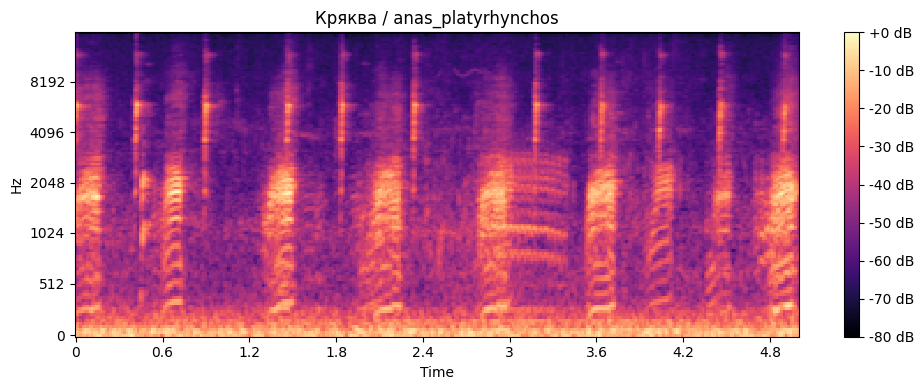

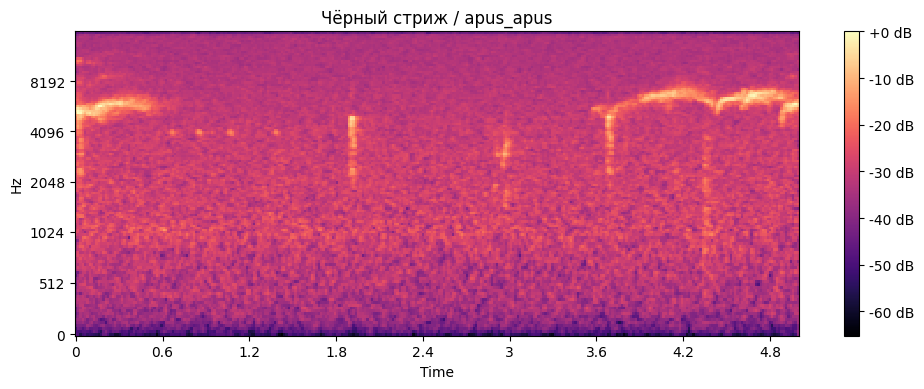

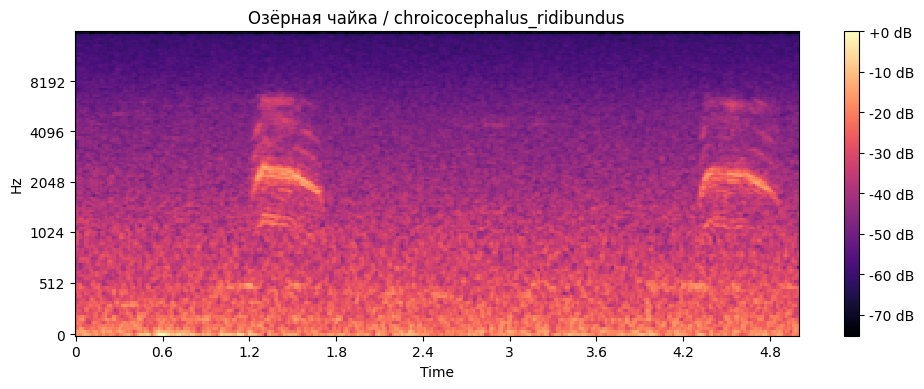

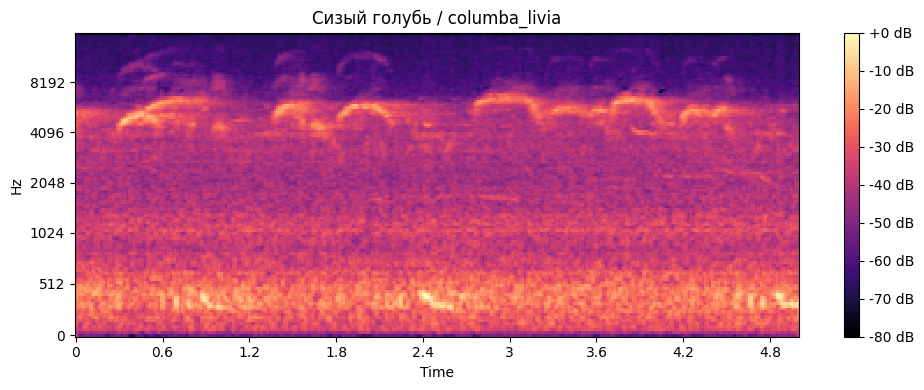

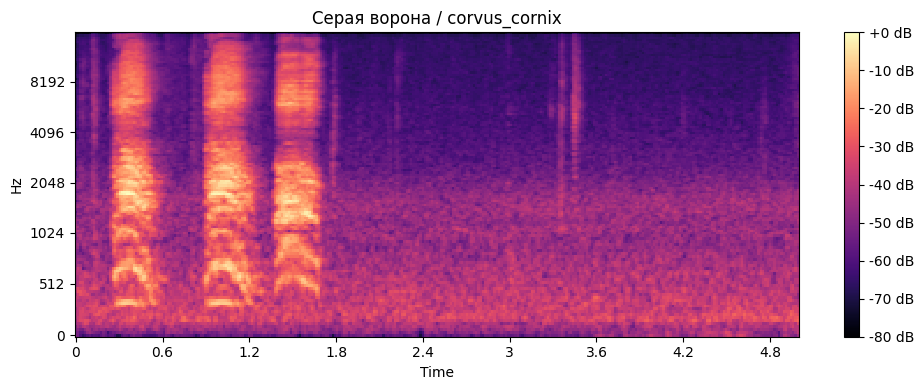

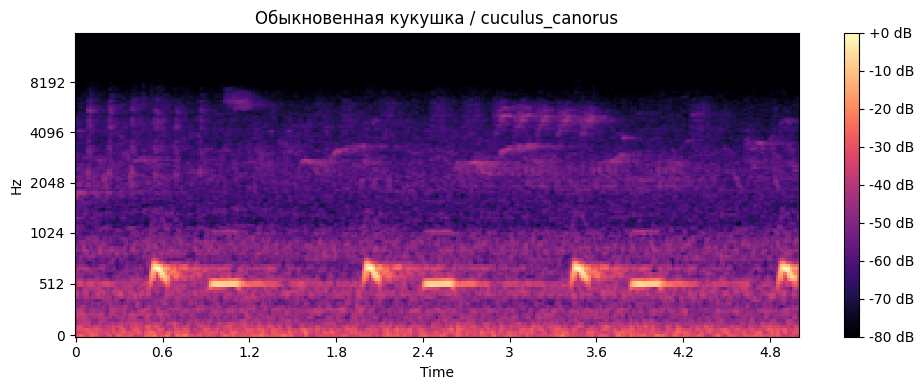

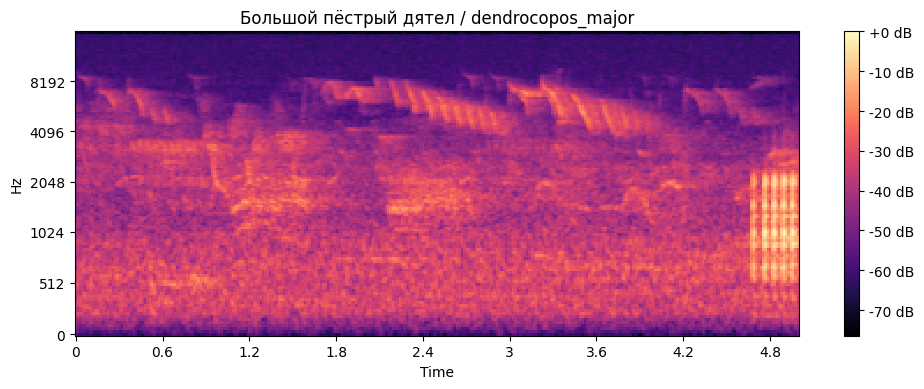

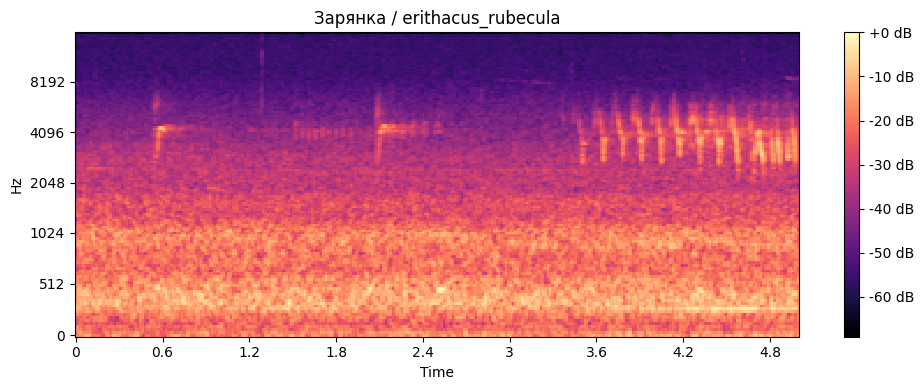

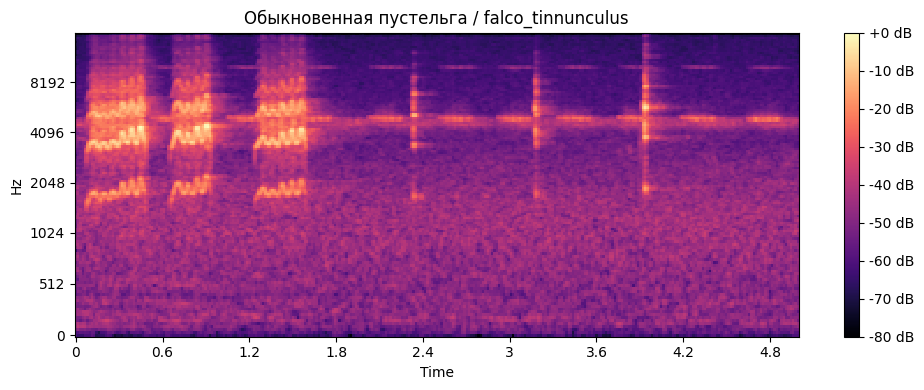

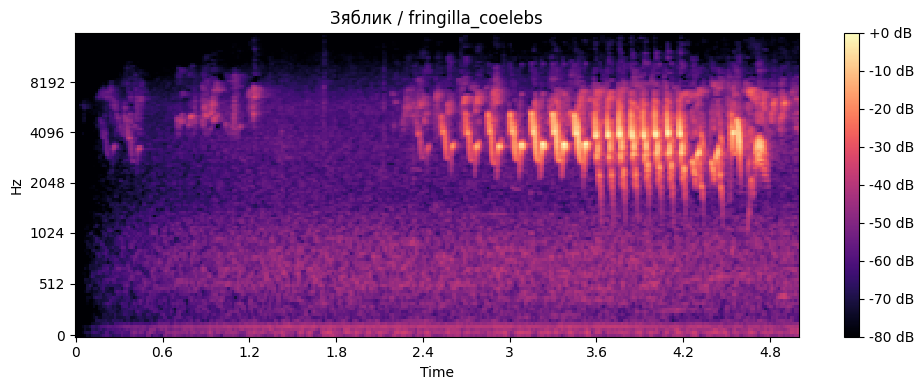

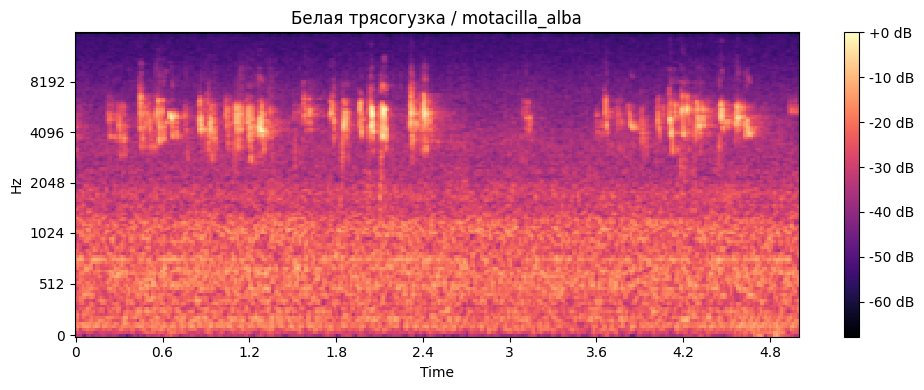

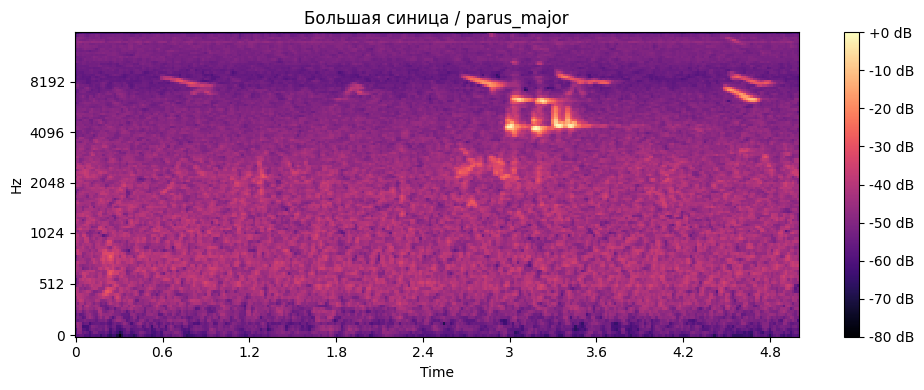

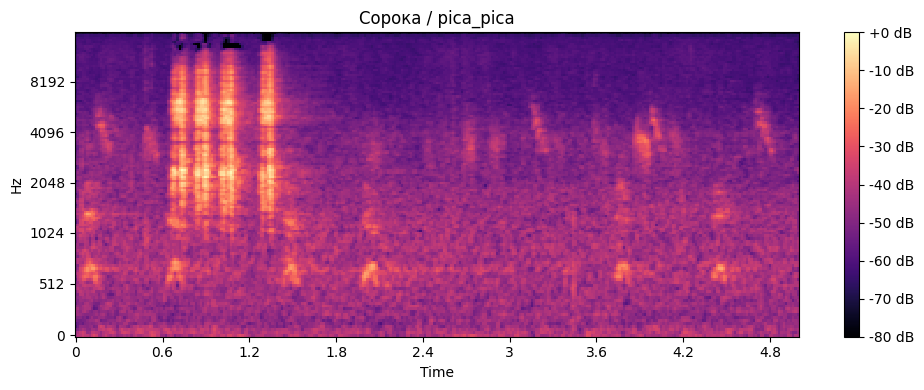

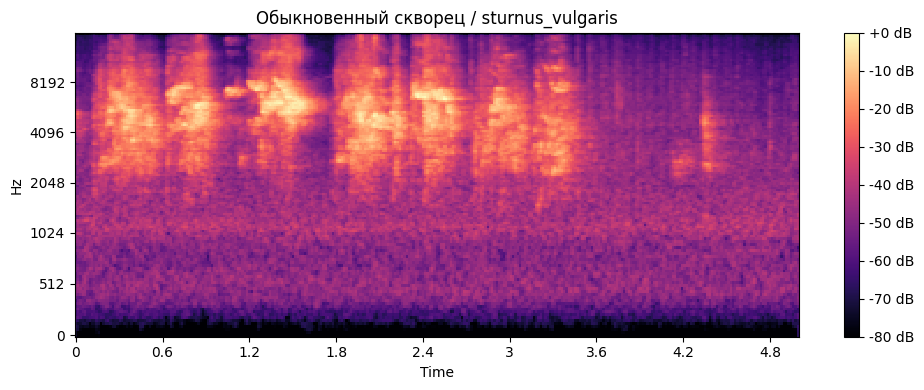

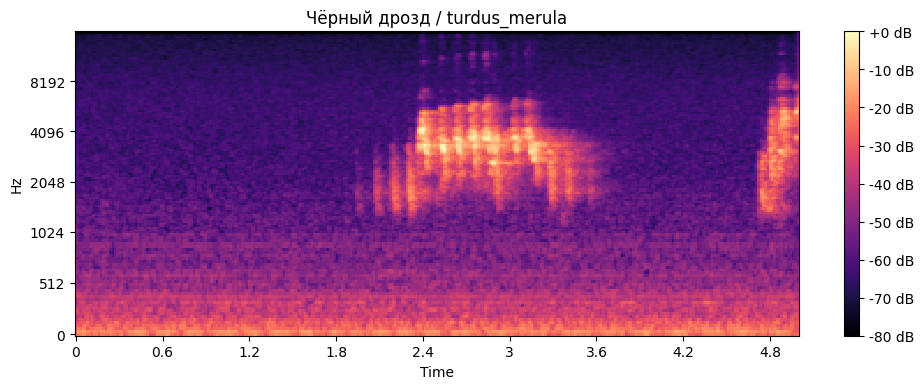

In [37]:
labels = train_segments["label"].unique()

for label in labels[:15]:
    sample = train_segments[train_segments["label"] == label].iloc[0]

    y = load_audio_segment(
        path=sample["local_path"],
        start_time=sample["start_time"],
        duration=sample["duration"],
        sr=SAMPLE_RATE
    )

    mel_db = audio_to_mel_spectrogram(y, sr=SAMPLE_RATE)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mel_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{sample['ru_name']} / {sample['label']}")
    plt.tight_layout()
    plt.show()

Красиво! Разные виды имеют разную частотно-временную структуру (кукушка — периодические низкочастотные всплески, стриж — широкополосный шум. Узнаваемые паттерны)

### Кодирование меток классов

Строковые названия видов птиц преобразуются в числовые метки (от 0 до 14), которые можно использовать при обучении модели. Также сохраняется словарь (JSON) соответствия между названиями классов и их числовыми индексами (будет нужен для инференса)

In [38]:
labels = sorted(train_segments["label"].unique())

label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

label_to_idx

train_segments["target"] = train_segments["label"].map(label_to_idx)
val_segments["target"] = val_segments["label"].map(label_to_idx)
test_segments["target"] = test_segments["label"].map(label_to_idx)

train_segments.to_csv(SEGMENTS_DIR / "train_segments_balanced.csv", index=False)
val_segments.to_csv(SEGMENTS_DIR / "val_segments.csv", index=False)
test_segments.to_csv(SEGMENTS_DIR / "test_segments.csv", index=False)

In [39]:
import json

LABELS_PATH = PROJECT_DIR / "data" / "processed" / "label_to_idx.json"

with open(LABELS_PATH, "w", encoding="utf-8") as f:
    json.dump(label_to_idx, f, ensure_ascii=False, indent=2)

### Итог этапа преобразования аудио

В результате был подготовлен пайплайн для загрузки аудиофрагментов и преобразования их в Mel-спектрограммы. Также были созданы числовые метки классов и сохранён словарь соответствий. Эти данные будут использоваться на следующем этапе для создания Dataset/DataLoader и обучения нейронной сети.

## Обучение

Для обучения используется отдельный датасет из 175 записей на класс (немного меньше, чем было изначально(200) - для скорости). Данные скачиваются заново во временную папку Colab (/content/birdvoice_audio). Это вынужденное решение: Colab не даёт прямого доступа к Drive со скоростью, достаточной для обучения; локальный SSD быстрее в разы.

In [40]:
matches = []

for path in PROJECT_DIR.rglob("*.csv"):
    name = path.name.lower()
    if "downloaded" in name or "final" in name or "15birds" in name:
        matches.append(path)

for m in matches:
    print(m)

/content/drive/MyDrive/birdvoice_project/data/raw/xeno_canto/metadata/xeno_canto_15birds_non_russia_full_metadata.csv
/content/drive/MyDrive/birdvoice_project/data/raw/xeno_canto/metadata/xeno_canto_15birds_final_counts.csv
/content/drive/MyDrive/birdvoice_project/data/raw/xeno_canto/metadata/xeno_canto_15birds_non_russia_final_metadata.csv
/content/drive/MyDrive/birdvoice_project/data/raw/xeno_canto/metadata/xeno_canto_15birds_non_russia_downloaded_metadata.csv


In [55]:
from sklearn.model_selection import train_test_split
from time import sleep
import requests

CONTENT_AUDIO_DIR = Path("/content/birdvoice_audio")
CONTENT_AUDIO_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_OUT = Path("/content/birdvoice_outputs")
LOCAL_OUT.mkdir(parents=True, exist_ok=True)

# 1. Берём 175 записей на каждый класс
N_PER_CLASS = 175

metadata_exp = (
    metadata_15_non_russia
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

print("Selected metadata:")
print(metadata_exp["label"].value_counts())
print("Total:", len(metadata_exp))


# 2. Скачиваем аудио во временную папку Colab
downloaded_rows = []

for label, group in metadata_exp.groupby("label"):
    label_dir = CONTENT_AUDIO_DIR / label
    label_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nDownloading {label}: {len(group)} files")

    for _, row in tqdm(group.iterrows(), total=len(group), desc=label):
        xc_id = str(row["id"])
        download_url = f"https://xeno-canto.org/{xc_id}/download"

        ext = "mp3"
        if "file-name" in row and isinstance(row["file-name"], str):
            if "." in row["file-name"]:
                ext = row["file-name"].split(".")[-1].lower()

        out_path = label_dir / f"XC{xc_id}.{ext}"

        if out_path.exists():
            row_dict = row.to_dict()
            row_dict["local_path"] = str(out_path)
            downloaded_rows.append(row_dict)
            continue

        try:
            r = requests.get(download_url, timeout=60, allow_redirects=True)
            r.raise_for_status()

            with open(out_path, "wb") as f:
                f.write(r.content)

            row_dict = row.to_dict()
            row_dict["local_path"] = str(out_path)
            downloaded_rows.append(row_dict)

            sleep(0.2)

        except Exception as e:
            print("Failed:", xc_id, e)

downloaded_metadata_content = pd.DataFrame(downloaded_rows)

print("\nDownloaded:")
print(downloaded_metadata_content["label"].value_counts())
print("Total downloaded:", len(downloaded_metadata_content))


# 3. Train / validation / test split по исходным аудиофайлам
train_df, temp_df = train_test_split(
    downloaded_metadata_content,
    test_size=0.30,
    stratify=downloaded_metadata_content["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


# 4. Считаем длительность аудио
def get_audio_duration(path):
    try:
        return librosa.get_duration(path=path)
    except Exception:
        return None

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    tqdm.pandas(desc=f"Durations {name}")
    df["duration_sec"] = df["local_path"].progress_apply(get_audio_duration)
    print(name)
    print(df["duration_sec"].describe())


# 5. Создаём 5-секундные сегменты
SEGMENT_DURATION = 5.0
MAX_SEGMENTS_PER_RECORDING = 5

def create_segments_metadata(
    df,
    split_name,
    segment_duration=5.0,
    max_segments_per_recording=5
):
    segments = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Creating {split_name} segments"):
        path = row["local_path"]
        label = row["label"]
        duration = row["duration_sec"]

        if pd.isna(duration) or duration < 1.0:
            continue

        if duration <= segment_duration:
            starts = [0.0]
        else:
            max_start = duration - segment_duration

            n_segments = min(
                int(duration // segment_duration),
                max_segments_per_recording
            )

            starts = np.linspace(0, max_start, n_segments)

        for i, start in enumerate(starts):
            segment_id = f"{split_name}_{row['id']}_{i}"

            segments.append({
                "segment_id": segment_id,
                "split": split_name,
                "label": label,
                "ru_name": row.get("ru_name", None),
                "en_name": row.get("en_name", None),
                "scientific_name": row.get("scientific_name", None),
                "recording_id": row["id"],
                "local_path": path,
                "start_time": float(start),
                "duration": segment_duration,
                "original_duration": duration
            })

    return pd.DataFrame(segments)

train_segments = create_segments_metadata(
    train_df,
    split_name="train",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

val_segments = create_segments_metadata(
    val_df,
    split_name="val",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

test_segments = create_segments_metadata(
    test_df,
    split_name="test",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

print("Train segments:", train_segments.shape)
print("Val segments:", val_segments.shape)
print("Test segments:", test_segments.shape)

print("\nTRAIN")
print(train_segments["label"].value_counts())

print("\nVAL")
print(val_segments["label"].value_counts())

print("\nTEST")
print(test_segments["label"].value_counts())


# 6. Кодируем классы
labels = sorted(train_segments["label"].unique())

label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

train_segments["target"] = train_segments["label"].map(label_to_idx)
val_segments["target"] = val_segments["label"].map(label_to_idx)
test_segments["target"] = test_segments["label"].map(label_to_idx)

num_classes = len(label_to_idx)

print("Num classes:", num_classes)
print(label_to_idx)

/tmp/ipykernel_6134/2540710062.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_PER_CLASS), random_state=42))


Selected metadata:
label
anas_platyrhynchos            175
apus_apus                     175
chroicocephalus_ridibundus    175
corvus_cornix                 175
cuculus_canorus               175
dendrocopos_major             175
erithacus_rubecula            175
parus_major                   175
falco_tinnunculus             175
fringilla_coelebs             175
motacilla_alba                175
sturnus_vulgaris              175
pica_pica                     175
turdus_merula                 175
columba_livia                 174
Name: count, dtype: int64
Total: 2624



anas_platyrhynchos: 100%|██████████| 175/175 [00:00<00:00, 1123.58it/s]


apus_apus: 100%|██████████| 175/175 [00:00<00:00, 1411.19it/s]


chroicocephalus_ridibundus: 100%|██████████| 175/175 [00:00<00:00, 1108.43it/s]


...

val
count     394.000000
mean       59.711594
std       120.609530
min         2.179042
25%        12.768129
50%        29.732313
75%        64.764534
max      1809.172834
Name: duration_sec, dtype: float64


Durations test: 100%|██████████| 394/394 [00:00<00:00, 3171.05it/s]


test
count    394.000000
mean      59.827062
std       96.787971
min        0.982766
25%       11.726042
50%       28.045302
75%       66.108114
max      899.897375
Name: duration_sec, dtype: float64


Creating test segments: 100%|██████████| 394/394 [00:00<00:00, 4542.87it/s]


Train segments: (6764, 11)
Val segments: (1450, 11)
Test segments: (1429, 11)

TRAIN
label
erithacus_rubecula            554
parus_major                   551
fringilla_coelebs             550
turdus_merula                 509
sturnus_vulgaris              508
dendrocopos_major             490
pica_pica                     487
cuculus_canorus               453
columba_livia                 444
chroicocephalus_ridibundus    421
falco_tinnunculus             411
motacilla_alba                409
anas_platyrhynchos            364
apus_apus                     341
corvus_cornix                 272
Name: count, dtype: int64

VAL
label
erithacus_rubecula            121
turdus_merula                 118
fringilla_coelebs             118
parus_major                   107
dendrocopos_major             104
sturnus_vulgaris              102
pica_pica                      99
falco_tinnunculus              99
chroicocephalus_ridibundus     99
cuculus_canorus                95
columba_livia         

175 записей × 15 классов = 2625 файлов (за вычетом голубя — 174).

Сплит: Train 6764 / Val 1450 / Test 1429.

In [47]:
import random
import torch


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

SAMPLE_RATE = 32000
SEGMENT_DURATION = 5.0

N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

BATCH_SIZE = 32
NUM_EPOCHS_AUG = 10
LEARNING_RATE = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [48]:
def load_audio_segment(path, start_time, duration, sr=32000):
    y, _ = librosa.load(
        path,
        sr=sr,
        mono=True,
        offset=float(start_time),
        duration=float(duration)
    )

    target_length = int(sr * duration)

    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))

    if len(y) > target_length:
        y = y[:target_length]

    return y


def audio_to_mel_spectrogram(y, sr=32000, n_mels=128, n_fft=2048, hop_length=512):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

In [50]:
from torch.utils.data import Dataset, DataLoader

def spec_augment(mel, max_time_mask=30, max_freq_mask=15):
    mel = mel.copy()

    n_mels, n_steps = mel.shape

    freq_mask = np.random.randint(0, max_freq_mask + 1)
    if freq_mask > 0:
        f0 = np.random.randint(0, max(1, n_mels - freq_mask))
        mel[f0:f0 + freq_mask, :] = mel.mean()

    time_mask = np.random.randint(0, max_time_mask + 1)
    if time_mask > 0:
        t0 = np.random.randint(0, max(1, n_steps - time_mask))
        mel[:, t0:t0 + time_mask] = mel.mean()

    return mel


class BirdAudioDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        y = load_audio_segment(
            path=row["local_path"],
            start_time=row["start_time"],
            duration=row["duration"],
            sr=SAMPLE_RATE
        )

        mel = audio_to_mel_spectrogram(
            y,
            sr=SAMPLE_RATE,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        if self.augment:
            mel = spec_augment(mel)

        mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        target = torch.tensor(row["target"], dtype=torch.long)

        return mel, target

BirdAudioDataset загружает сегмент аудио → строит mel-спектрограмму → нормализует (z-score) → возвращает тензор (1, 128, 313).

In [51]:
train_dataset_aug = BirdAudioDataset(train_segments, augment=True)
val_dataset_aug = BirdAudioDataset(val_segments, augment=False)
test_dataset_aug = BirdAudioDataset(test_segments, augment=False)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader_aug = DataLoader(
    val_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader_aug = DataLoader(
    test_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

Строим BirdCNN с четырьмя блоками: Conv2d+BN+ReLU+MaxPool с нарастающим числом фильтров (32→64→128→256). Заканчивается AdaptiveAvgPool и линейным классификатором.
Всего ~3М параметров. Это простая, но эффективная архитектура для спектрограмм.

In [56]:
import torch.nn as nn
class BirdCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_aug = BirdCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_aug = optim.Adam(
    model_aug.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

MODEL_AUG_PATH = LOCAL_OUT / "bird_cnn_specaugment_175_best.pt"

In [57]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_targets = []

    for x, y in tqdm(loader, desc="Training", leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, f1


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating", leave=False):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)

            preds = logits.argmax(dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, f1, all_targets, all_preds

In [ ]:
best_val_f1_aug = 0
history_aug = []

PATIENCE = 3
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS_AUG + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer_aug,
        criterion,
        device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model_aug,
        val_loader_aug,
        criterion,
        device
    )

    history_aug.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1_aug:
        best_val_f1_aug = val_f1
        torch.save(model_aug.state_dict(), MODEL_AUG_PATH)
        epochs_without_improvement = 0
        print("Saved best improved model")
    else:
        epochs_without_improvement += 1
        print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping")
        break

Training:  94%|█████████▍| 200/212 [04:34<00:14,  1.23s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Training:  98%|█████████▊| 207/212 [04:44<00:07,  1.44s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 01 | train_loss=2.0582, train_acc=0.3442, train_f1=0.3327 | val_loss=2.0786, val_acc=0.3503, val_f1=0.3296
Saved best improved model


Training:  52%|█████▏    | 111/212 [02:44<02:58,  1.76s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Training:  80%|███████▉  | 169/212 [04:09<01:02,  1.45s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 02 | train_loss=1.8225, train_acc=0.4160, train_f1=0.4128 | val_loss=1.8520, val_acc=0.4283, val_f1=0.4200
Saved best improved model


Training:  30%|██▉       | 63/212 [01:22<03:18,  1.33s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Training:  78%|███████▊  | 166/212 [03:57<01:01,  1.34s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 03 | train_loss=1.7127, train_acc=0.4576, train_f1=0.4575 | val_loss=1.5990, val_acc=0.5076, val_f1=0.5144
Saved best improved model


Training:  48%|████▊     | 101/212 [03:23<04:44,  2.57s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Training:  71%|███████   | 150/212 [04:48<01:55,  1.86s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Epoch 04 | train_loss=1.5935, train_acc=0.5019, train_f1=0.5038 | val_loss=1.8957, val_acc=0.4152, val_f1=0.4003
No improvement: 1/3


Training:   6%|▌         | 13/212 [00:19<04:16,  1.29s/it]/tmp/ipykernel_6134/2615140440.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Training:  50%|████▉     | 105/212 [02:19<02:10,  1.22s/it]

Обращается внимание на нестабильность val_loss: на epoch 3 и 6 он резко возрастает. Это типично при SpecAugment на небольших выборках — аугментация мешает быстрой сходимости, но улучшает обобщение. Early stopping сработал на 8 эпохе (patience=3).

Разрыв между train_f1 (~ 0.60) и val_f1 (~0 .49) на  лучшем чекпойнте умеренный — небольшой оверфиттинг.

In [ ]:
model_aug.load_state_dict(torch.load(MODEL_AUG_PATH, map_location=device))

test_loss_aug, test_acc_aug, test_f1_aug, y_true_aug, y_pred_aug = evaluate(
    model_aug,
    test_loader_aug,
    criterion,
    device
)

print("IMPROVED 175 TEST LOSS:", test_loss_aug)
print("IMPROVED 175 TEST ACC:", test_acc_aug)
print("IMPROVED 175 TEST MACRO-F1:", test_f1_aug)

Для 15-классовой задачи с случайным угадыванием (baseline = 1/15 ≈ 0.067) результат в 4.56 ращ лучше случайного!! Но заметен большой разброс по классам. Кукушка и стриж имеют очень характерные, акустически уникальные вокализации, которые легко распознаются. Зарянка и певчие виды со схожим диапазоном частот путаются между собой. Голубь распознаётся с высоким recall (0.89), но низкой precision. Вместо него модель часто предсказывает голубя.

In [ ]:
target_names = [idx_to_label[i] for i in range(num_classes)]

report_aug = classification_report(
    y_true_aug,
    y_pred_aug,
    target_names=target_names,
    output_dict=True
)

report_aug_df = pd.DataFrame(report_aug).transpose()
report_aug_df.to_csv(LOCAL_OUT / "classification_report_specaugment_175.csv")

report_aug_df

In [ ]:
cm_aug = confusion_matrix(y_true_aug, y_pred_aug)

plt.figure(figsize=(12, 10))
plt.imshow(cm_aug)
plt.title("Confusion Matrix — CNN + SpecAugment, 175 recordings/class")
plt.colorbar()

plt.xticks(range(num_classes), target_names, rotation=90)
plt.yticks(range(num_classes), target_names)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig(LOCAL_OUT / "confusion_matrix_specaugment_175.png", dpi=200)
plt.show()

In [ ]:
history_aug_df = pd.DataFrame(history_aug)
history_aug_df.to_csv(LOCAL_OUT / "training_history_specaugment_175.csv", index=False)

history_aug_df

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,2.418761,0.224547,0.197707,2.251537,0.271129,0.234388
1,2,2.015482,0.364203,0.344687,1.959449,0.373901,0.324897
2,3,1.790572,0.439151,0.433563,2.324366,0.313049,0.287892
3,4,1.617099,0.507717,0.506248,1.668547,0.490196,0.484980
4,5,1.498016,0.542446,0.543988,1.604024,0.482759,0.486106
5,6,1.415390,0.567379,0.569330,2.312652,0.345504,0.340387
6,7,1.357140,0.589344,0.592240,1.931706,0.421907,0.436809
7,8,1.316620,0.597804,0.598774,2.128286,0.395538,0.426045


In [ ]:
summary_175 = pd.DataFrame([{
    "model": "CNN + SpecAugment",
    "n_per_class": 175,
    "best_val_f1": best_val_f1_aug,
    "test_loss": test_loss_aug,
    "test_accuracy": test_acc_aug,
    "test_macro_f1": test_f1_aug
}])

summary_175.to_csv(LOCAL_OUT / "summary_specaugment_175.csv", index=False)

summary_175

,model,n_per_class,best_val_f1,test_loss,test_accuracy,test_macro_f1
0,CNN + SpecAugment,175,0.486106,1.701521,0.45574,0.456131


Результаты норм, но не супер. Можем заметить что некоторые птички очень плохо угадываются. Поэтому хочу провести эксперимент с меньшим кол-вом птиц.
Выбрали 10 видов с наибольшей акустической различимостью (убрали зяблика, чёрного дрозда, трясогузку, скворца, чайку. В 15-классовом эксперименте они давали самый низкий F1 или путались с другими).
Все файлы уже скачаны — берём подмножество из существующего датасета.

In [ ]:
# Отдельные папки для нового эксперимента
CONTENT_AUDIO_DIR_10 = Path("/content/birdvoice_audio_10classes")
CONTENT_AUDIO_DIR_10.mkdir(parents=True, exist_ok=True)

LOCAL_OUT_10 = Path("/content/birdvoice_outputs_10classes")
LOCAL_OUT_10.mkdir(parents=True, exist_ok=True)

print("Audio dir for 10-class experiment:", CONTENT_AUDIO_DIR_10)
print("Outputs dir for 10-class experiment:", LOCAL_OUT_10)

Audio dir for 10-class experiment: /content/birdvoice_audio_10classes
Outputs dir for 10-class experiment: /content/birdvoice_outputs_10classes


In [ ]:
selected_labels_10 = [
    "cuculus_canorus",       # кукушка
    "apus_apus",             # чёрный стриж
    "corvus_cornix",         # серая ворона
    "falco_tinnunculus",     # обыкновенная пустельга
    "dendrocopos_major",     # большой пёстрый дятел
    "anas_platyrhynchos",    # кряква
    "erithacus_rubecula",    # зарянка
    "pica_pica",             # сорока
    "columba_livia",         # сизый голубь
    "parus_major"            # большая синица
]

# Берём 10 классов из уже скачанного датасета 15 классов
metadata_exp_10 = downloaded_metadata_content[
    downloaded_metadata_content["label"].isin(selected_labels_10)
].copy()

print("Selected metadata for 10-class experiment:")
print(metadata_exp_10["label"].value_counts())
print("Total:", len(metadata_exp_10))

# Проверяем, что аудиофайлы реально существуют
metadata_exp_10["file_exists"] = metadata_exp_10["local_path"].apply(lambda x: Path(x).exists())

print("\nFile exists check:")
print(metadata_exp_10["file_exists"].value_counts())
print("Missing:", (~metadata_exp_10["file_exists"]).sum())

Selected metadata for 10-class experiment:
label
anas_platyrhynchos    175
apus_apus             175
corvus_cornix         175
cuculus_canorus       175
dendrocopos_major     175
erithacus_rubecula    175
parus_major           175
falco_tinnunculus     175
pica_pica             175
columba_livia         174
Name: count, dtype: int64
Total: 1749

File exists check:
file_exists
True    1749
Name: count, dtype: int64
Missing: 0


все 1749 файлов на месте

In [ ]:
train_df_10, temp_df_10 = train_test_split(
    metadata_exp_10,
    test_size=0.30,
    stratify=metadata_exp_10["label"],
    random_state=42
)

val_df_10, test_df_10 = train_test_split(
    temp_df_10,
    test_size=0.50,
    stratify=temp_df_10["label"],
    random_state=42
)

print("Train:", train_df_10.shape)
print("Val:", val_df_10.shape)
print("Test:", test_df_10.shape)

print("\nTRAIN")
print(train_df_10["label"].value_counts())

print("\nVAL")
print(val_df_10["label"].value_counts())

print("\nTEST")
print(test_df_10["label"].value_counts())

Train: (1224, 45)
Val: (262, 45)
Test: (263, 45)

TRAIN
label
erithacus_rubecula    123
parus_major           123
anas_platyrhynchos    123
apus_apus             123
dendrocopos_major     122
corvus_cornix         122
columba_livia         122
cuculus_canorus       122
falco_tinnunculus     122
pica_pica             122
Name: count, dtype: int64

VAL
label
falco_tinnunculus     27
cuculus_canorus       27
erithacus_rubecula    26
corvus_cornix         26
apus_apus             26
columba_livia         26
dendrocopos_major     26
pica_pica             26
anas_platyrhynchos    26
parus_major           26
Name: count, dtype: int64

TEST
label
dendrocopos_major     27
pica_pica             27
corvus_cornix         27
falco_tinnunculus     26
columba_livia         26
parus_major           26
erithacus_rubecula    26
apus_apus             26
anas_platyrhynchos    26
cuculus_canorus       26
Name: count, dtype: int64


Баланс по классам хороший! 122–123 на класс в трейне, 26-27 в тесте и валидации

In [ ]:
def get_audio_duration(path):
    try:
        return librosa.get_duration(path=path)
    except Exception:
        return None

for name, df in [("train", train_df_10), ("val", val_df_10), ("test", test_df_10)]:
    tqdm.pandas(desc=f"Durations {name}")
    df["duration_sec"] = df["local_path"].progress_apply(get_audio_duration)
    print(name)
    print(df["duration_sec"].describe())

Durations train: 100%|██████████| 1224/1224 [00:00<00:00, 8027.31it/s]


train
count    1224.000000
mean       51.818415
std        90.792527
min         0.983833
25%        11.475677
50%        25.871984
75%        53.843384
max      1316.511270
Name: duration_sec, dtype: float64


Durations val: 100%|██████████| 262/262 [00:00<00:00, 7171.29it/s]


val
count     262.000000
mean       61.266516
std       105.232241
min         1.154467
25%        11.578396
50%        27.988491
75%        68.623895
max      1050.564417
Name: duration_sec, dtype: float64


Durations test: 100%|██████████| 263/263 [00:00<00:00, 7018.84it/s]

test
count     263.000000
mean       52.882334
std       100.855085
min         1.294898
25%        10.736275
50%        26.763500
75%        54.210524
max      1103.304739
Name: duration_sec, dtype: float64


 А здесь снова дисбаланс: у corvus_cornix в трейне 262 сегмента,  у erithacus_rubecula - 548. Ворона оказывается наименее представленным классом: у неё короткие записи и мало файлов.

In [ ]:
SEGMENT_DURATION = 5.0
MAX_SEGMENTS_PER_RECORDING = 5

train_segments_10 = create_segments_metadata(
    train_df_10,
    split_name="train_10",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

val_segments_10 = create_segments_metadata(
    val_df_10,
    split_name="val_10",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

test_segments_10 = create_segments_metadata(
    test_df_10,
    split_name="test_10",
    segment_duration=SEGMENT_DURATION,
    max_segments_per_recording=MAX_SEGMENTS_PER_RECORDING
)

print("Train segments:", train_segments_10.shape)
print("Val segments:", val_segments_10.shape)
print("Test segments:", test_segments_10.shape)

print("\nTRAIN")
print(train_segments_10["label"].value_counts())

print("\nVAL")
print(val_segments_10["label"].value_counts())

print("\nTEST")
print(test_segments_10["label"].value_counts())

Creating test_10 segments: 100%|██████████| 263/263 [00:00<00:00, 7703.93it/s]

Train segments: (4353, 11)
Val segments: (950, 11)
Test segments: (939, 11)

TRAIN
label
erithacus_rubecula    548
parus_major           547
dendrocopos_major     484
columba_livia         464
cuculus_canorus       453
pica_pica             452
falco_tinnunculus     392
anas_platyrhynchos    390
apus_apus             361
corvus_cornix         262
Name: count, dtype: int64

VAL
label
erithacus_rubecula    115
parus_major           113
dendrocopos_major     110
falco_tinnunculus     106
cuculus_canorus       102
apus_apus              97
pica_pica              95
columba_livia          83
anas_platyrhynchos     80
corvus_cornix          49
Name: count, dtype: int64

TEST
label
erithacus_rubecula    119
pica_pica             118
parus_major           111
falco_tinnunculus      97
dendrocopos_major      95
cuculus_canorus        91
columba_livia          84
apus_apus              80
anas_platyrhynchos     79
corvus_cornix          65
Name: count, dtype: int64


In [ ]:
labels_10 = sorted(train_segments_10["label"].unique())

label_to_idx_10 = {label: idx for idx, label in enumerate(labels_10)}
idx_to_label_10 = {idx: label for label, idx in label_to_idx_10.items()}

train_segments_10["target"] = train_segments_10["label"].map(label_to_idx_10)
val_segments_10["target"] = val_segments_10["label"].map(label_to_idx_10)
test_segments_10["target"] = test_segments_10["label"].map(label_to_idx_10)

num_classes_10 = len(label_to_idx_10)

print("Num classes:", num_classes_10)
print(label_to_idx_10)

Num classes: 10
{'anas_platyrhynchos': 0, 'apus_apus': 1, 'columba_livia': 2, 'corvus_cornix': 3, 'cuculus_canorus': 4, 'dendrocopos_major': 5, 'erithacus_rubecula': 6, 'falco_tinnunculus': 7, 'parus_major': 8, 'pica_pica': 9}


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

SAMPLE_RATE = 32000
SEGMENT_DURATION = 5.0

N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

BATCH_SIZE = 32
NUM_EPOCHS_10 = 10
LEARNING_RATE = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Обучение - 10 классов

In [ ]:
class BirdAudioDataset10(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        y = load_audio_segment(
            path=row["local_path"],
            start_time=row["start_time"],
            duration=row["duration"],
            sr=SAMPLE_RATE
        )

        mel = audio_to_mel_spectrogram(
            y,
            sr=SAMPLE_RATE,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        if self.augment:
            mel = spec_augment(mel)

        mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        target = torch.tensor(row["target"], dtype=torch.long)

        return mel, target

In [ ]:
train_dataset_10 = BirdAudioDataset10(train_segments_10, augment=True)
val_dataset_10 = BirdAudioDataset10(val_segments_10, augment=False)
test_dataset_10 = BirdAudioDataset10(test_segments_10, augment=False)

train_loader_10 = DataLoader(
    train_dataset_10,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader_10 = DataLoader(
    val_dataset_10,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader_10 = DataLoader(
    test_dataset_10,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

x_batch, y_batch = next(iter(train_loader_10))

print(x_batch.shape)
print(y_batch.shape)

torch.Size([32, 1, 128, 313])
torch.Size([32])


Те же гиперпараметры, та же архитектура CNN, только num_classes=10.

BirdAudioDataset10 — новый класс, идентичный BirdAudioDataset.

Форма батча: 32, 1, 128, 313 - всё правильно.

In [ ]:
model_10 = BirdCNN(num_classes=num_classes_10).to(device)

criterion_10 = nn.CrossEntropyLoss()

optimizer_10 = optim.Adam(
    model_10.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

MODEL_10_PATH = LOCAL_OUT_10 / "bird_cnn_specaugment_10classes_175_best.pt"

model_10

BirdCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [ ]:
best_val_f1_10 = 0
history_10 = []

PATIENCE = 3
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS_10 + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model_10,
        train_loader_10,
        optimizer_10,
        criterion_10,
        device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model_10,
        val_loader_10,
        criterion_10,
        device
    )

    history_10.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1_10:
        best_val_f1_10 = val_f1
        torch.save(model_10.state_dict(), MODEL_10_PATH)
        epochs_without_improvement = 0
        print("Saved best 10-class model")
    else:
        epochs_without_improvement += 1
        print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping")
        break

Epoch 01 | train_loss=1.9874, train_acc=0.2970, train_f1=0.2578 | val_loss=1.7966, val_acc=0.3705, val_f1=0.3244
Saved best 10-class model


Epoch 02 | train_loss=1.5785, train_acc=0.4808, train_f1=0.4601 | val_loss=1.7257, val_acc=0.3737, val_f1=0.3357
Saved best 10-class model


Epoch 03 | train_loss=1.3537, train_acc=0.5594, train_f1=0.5570 | val_loss=3.1372, val_acc=0.1505, val_f1=0.1081
No improvement: 1/3


Epoch 04 | train_loss=1.2080, train_acc=0.6113, train_f1=0.6087 | val_loss=1.5463, val_acc=0.5011, val_f1=0.4820
Saved best 10-class model


Epoch 05 | train_loss=1.1253, train_acc=0.6377, train_f1=0.6364 | val_loss=1.2503, val_acc=0.5632, val_f1=0.5708
Saved best 10-class model


Epoch 06 | train_loss=1.0451, train_acc=0.6655, train_f1=0.6656 | val_loss=1.3822, val_acc=0.5589, val_f1=0.5491
No improvement: 1/3


Epoch 07 | train_loss=0.9904, train_acc=0.6892, train_f1=0.6888 | val_loss=2.5655, val_acc=0.3832, val_f1=0.3419
No improvement: 2/3


Epoch 08 | train_loss=0.9291, train_acc=0.7094, train_f1=0.7123 | val_loss=1.3608, val_acc=0.5779, val_f1=0.5540
No improvement: 3/3
Early stopping


На epoch 3 снова обвал val_f1 до 0.108 при train_f1=0.557. Это признак временного перефиттинга с последующим выходом из него. Нестабильность val обусловлена относительно маленьким val (262 файла) и сильной аугментацией.

In [ ]:
model_10.load_state_dict(torch.load(MODEL_10_PATH, map_location=device))

test_loss_10, test_acc_10, test_f1_10, y_true_10, y_pred_10 = evaluate(
    model_10,
    test_loader_10,
    criterion_10,
    device
)

print("10-CLASS TEST LOSS:", test_loss_10)
print("10-CLASS TEST ACC:", test_acc_10)
print("10-CLASS TEST MACRO-F1:", test_f1_10)

10-CLASS TEST LOSS: 1.3258033777578189
10-CLASS TEST ACC: 0.5601703940362087
10-CLASS TEST MACRO-F1: 0.5578679201338509


Прирост +10 по сравнению с 15 классами. Существенно!



In [ ]:
target_names_10 = [idx_to_label_10[i] for i in range(num_classes_10)]

report_10 = classification_report(
    y_true_10,
    y_pred_10,
    target_names=target_names_10,
    output_dict=True
)

report_10_df = pd.DataFrame(report_10).transpose()
report_10_df.to_csv(LOCAL_OUT_10 / "classification_report_10classes_175.csv")

report_10_df

,precision,recall,f1-score,support
anas_platyrhynchos,0.407692,0.670886,0.507177,79.00000
apus_apus,0.759259,0.512500,0.611940,80.00000
columba_livia,0.456000,0.678571,0.545455,84.00000
corvus_cornix,0.909091,0.307692,0.459770,65.00000
cuculus_canorus,0.945455,0.571429,0.712329,91.00000
dendrocopos_major,0.428571,0.473684,0.450000,95.00000
erithacus_rubecula,0.820000,0.344538,0.485207,119.00000
falco_tinnunculus,0.510638,0.742268,0.605042,97.00000
parus_major,0.717647,0.549550,0.622449,111.00000
pica_pica,0.488372,0.711864,0.579310,118.00000


Кукушка снова на первом месте! У ворон precision 0.91, но recall 0.31. Вороны определяются правильно, но 70% пропускается.

Скорее всего, это означает, что характерные каркающие вокализации распознаются хорошо, но ворона часто молчит или её запись разнообразна.

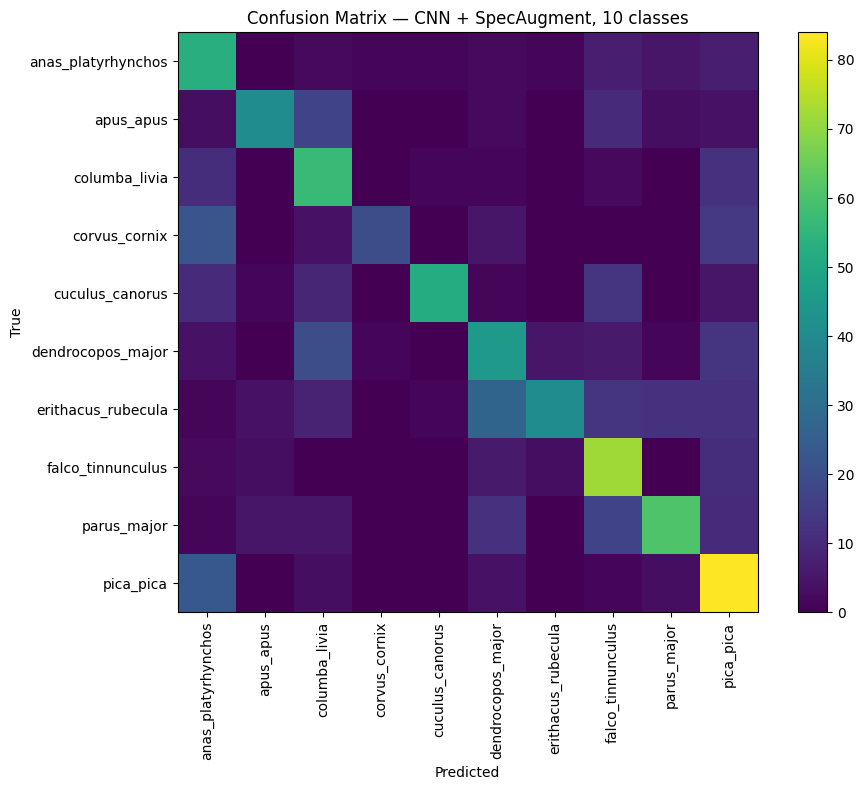

In [ ]:
cm_10 = confusion_matrix(y_true_10, y_pred_10)

plt.figure(figsize=(10, 8))
plt.imshow(cm_10)
plt.title("Confusion Matrix — CNN + SpecAugment, 10 classes")
plt.colorbar()

plt.xticks(range(num_classes_10), target_names_10, rotation=90)
plt.yticks(range(num_classes_10), target_names_10)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig(LOCAL_OUT_10 / "confusion_matrix_10classes_175.png", dpi=200)
plt.show()

In [ ]:
TEST_ACC_15 = 0.455740
TEST_F1_15 = 0.456131
BEST_VAL_F1_15 = 0.4861

In [ ]:
history_10_df = pd.DataFrame(history_10)
history_10_df.to_csv(LOCAL_OUT_10 / "training_history_10classes_175.csv", index=False)

summary_compare = pd.DataFrame([
    {
        "experiment": "15_classes_175",
        "model": "CNN + SpecAugment",
        "num_classes": 15,
        "n_per_class": 175,
        "best_val_f1": BEST_VAL_F1_15,
        "test_accuracy": TEST_ACC_15,
        "test_macro_f1": TEST_F1_15
    },
    {
        "experiment": "10_classes_175",
        "model": "CNN + SpecAugment",
        "num_classes": 10,
        "n_per_class": 175,
        "best_val_f1": best_val_f1_10,
        "test_accuracy": test_acc_10,
        "test_macro_f1": test_f1_10
    }
])

summary_compare.to_csv(LOCAL_OUT_10 / "summary_compare_15_vs_10.csv", index=False)

summary_compare

,experiment,model,num_classes,n_per_class,best_val_f1,test_accuracy,test_macro_f1
0,15_classes_175,CNN + SpecAugment,15,175,0.486100,0.45574,0.456131
1,10_classes_175,CNN + SpecAugment,10,175,0.570774,0.56017,0.557868


В итоге, уменьшение числа классов с 15 до 10 при том же объёме данных и дало прирост.
Это говорит о том, что убранные 5 классов были сложными и снижали общее качество из-за акустической схожести с остальными.



#### еще один эксперимент:
10 классов + более удачная нарезка активных фрагментов


In [ ]:

LOCAL_OUT_10_ACTIVE = Path("/content/birdvoice_outputs_10classes_active")
LOCAL_OUT_10_ACTIVE.mkdir(parents=True, exist_ok=True)

SEGMENT_DURATION = 5.0
MAX_SEGMENTS_PER_RECORDING = 5
SAMPLE_RATE = 32000


def get_active_starts(path, duration, segment_duration=5.0, max_segments=5, sr=32000):
    """
    Берём несколько 5-секундных окон с самой высокой RMS energy.
    Проще говоря: выбираем самые 'звучащие' куски файла.
    """
    try:
        y, sr = librosa.load(path, sr=sr, mono=True)
    except Exception:
        return []

    segment_len = int(segment_duration * sr)

    if len(y) <= segment_len:
        return [0.0]

    starts = []
    scores = []

    max_start_sample = len(y) - segment_len

    # идём по файлу шагом 1 секунда
    step = sr

    for start_sample in range(0, max_start_sample + 1, step):
        segment = y[start_sample:start_sample + segment_len]

        # громкость / активность фрагмента
        rms = np.sqrt(np.mean(segment ** 2))

        starts.append(start_sample / sr)
        scores.append(rms)

    if len(starts) == 0:
        return [0.0]

    # берём top-N самых активных окон
    best_idx = np.argsort(scores)[-max_segments:]

    best_starts = [starts[i] for i in best_idx]

    # сортируем по времени
    best_starts = sorted(best_starts)

    return best_starts


def create_active_segments_metadata(df, split_name):
    segments = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Active segments {split_name}"):
        path = row["local_path"]
        label = row["label"]
        duration = row["duration_sec"]

        if pd.isna(duration) or duration < 1:
            continue

        starts = get_active_starts(
            path=path,
            duration=duration,
            segment_duration=SEGMENT_DURATION,
            max_segments=MAX_SEGMENTS_PER_RECORDING,
            sr=SAMPLE_RATE
        )

        for i, start in enumerate(starts):
            segments.append({
                "segment_id": f"{split_name}_active_{row['id']}_{i}",
                "split": split_name,
                "label": label,
                "ru_name": row.get("ru_name", None),
                "en_name": row.get("en_name", None),
                "scientific_name": row.get("scientific_name", None),
                "recording_id": row["id"],
                "local_path": path,
                "start_time": float(start),
                "duration": SEGMENT_DURATION,
                "original_duration": duration,
                "selection_method": "top_rms_energy"
            })

    return pd.DataFrame(segments)

In [ ]:
train_segments_10_active = create_active_segments_metadata(train_df_10, "train_10")
val_segments_10_active = create_active_segments_metadata(val_df_10, "val_10")
test_segments_10_active = create_active_segments_metadata(test_df_10, "test_10")

print("Train:", train_segments_10_active.shape)
print("Val:", val_segments_10_active.shape)
print("Test:", test_segments_10_active.shape)

print("\nTRAIN")
print(train_segments_10_active["label"].value_counts())

print("\nVAL")
print(val_segments_10_active["label"].value_counts())

print("\nTEST")
print(test_segments_10_active["label"].value_counts())

In [ ]:
train_dataset_10_active = BirdAudioDataset10(train_segments_10_active, augment=True)
val_dataset_10_active = BirdAudioDataset10(val_segments_10_active, augment=False)
test_dataset_10_active = BirdAudioDataset10(test_segments_10_active, augment=False)

train_loader_10_active = DataLoader(
    train_dataset_10_active,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader_10_active = DataLoader(
    val_dataset_10_active,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader_10_active = DataLoader(
    test_dataset_10_active,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

x_batch, y_batch = next(iter(train_loader_10_active))

print(x_batch.shape)
print(y_batch.shape)

In [ ]:
model_10_active = BirdCNN(num_classes=num_classes_10_active).to(device)

criterion_10_active = nn.CrossEntropyLoss()

optimizer_10_active = optim.Adam(
    model_10_active.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

MODEL_10_ACTIVE_PATH = LOCAL_OUT_10_ACTIVE / "bird_cnn_10classes_active_best.pt"

best_val_f1_10_active = 0
history_10_active = []

PATIENCE = 3
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS_10 + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model_10_active,
        train_loader_10_active,
        optimizer_10_active,
        criterion_10_active,
        device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model_10_active,
        val_loader_10_active,
        criterion_10_active,
        device
    )

    history_10_active.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1_10_active:
        best_val_f1_10_active = val_f1
        torch.save(model_10_active.state_dict(), MODEL_10_ACTIVE_PATH)
        epochs_without_improvement = 0
        print("Saved best active model")
    else:
        epochs_without_improvement += 1
        print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping")
        break

In [ ]:
model_10_active.load_state_dict(
    torch.load(MODEL_10_ACTIVE_PATH, map_location=device)
)

test_loss_10_active, test_acc_10_active, test_f1_10_active, y_true_10_active, y_pred_10_active = evaluate(
    model_10_active,
    test_loader_10_active,
    criterion_10_active,
    device
)

print("ACTIVE 10-CLASS TEST LOSS:", test_loss_10_active)
print("ACTIVE 10-CLASS TEST ACC:", test_acc_10_active)
print("ACTIVE 10-CLASS TEST MACRO-F1:", test_f1_10_active)

In [ ]:
target_names_10_active = [idx_to_label_10[i] for i in range(num_classes_10_active)]

report_10_active = classification_report(
    y_true_10_active,
    y_pred_10_active,
    target_names=target_names_10_active,
    output_dict=True,
    zero_division=0
)

report_10_active_df = pd.DataFrame(report_10_active).transpose()

report_10_active_df.to_csv(
    LOCAL_OUT_10_ACTIVE / "classification_report_10classes_active.csv"
)

report_10_active_df

In [ ]:
cm_10_active = confusion_matrix(y_true_10_active, y_pred_10_active)

plt.figure(figsize=(10, 8))
plt.imshow(cm_10_active)
plt.title("Confusion Matrix — CNN + active segmentation, 10 classes")
plt.colorbar()

plt.xticks(range(num_classes_10_active), target_names_10_active, rotation=90)
plt.yticks(range(num_classes_10_active), target_names_10_active)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig(LOCAL_OUT_10_ACTIVE / "confusion_matrix_10classes_active.png", dpi=200)
plt.show()

### Выводы: эксперименты с обучением на 10 классах

Дополнительно были проведены:
1) эксперимент с уменьшением числа классов с 15 до 10. Из исходного набора были исключены виды, которые в предыдущем эксперименте давали наиболее низкие значения F1-score или сильнее всего путались с другими классами. При сохранении того же подхода к обучению, CNN + SpecAugment, качество выросло: test macro-F1 увеличился с 0.456 до 0.558, а accuracy - с 0.456 до 0.560. Это показывает, что сложность задачи существенно зависит не только от числа классов, но и от акустической различимости выбранных видов.
2) Во втором эксперименте была изменена только нарезка аудио. Вместо равномерного выбора 5-секундных фрагментов из записи выбирались наиболее активные окна по RMS energy.
Это важно, потому что метка вида относится ко всей записи, но птица может петь не на всём протяжении файла. Поэтому равномерная нарезка может добавлять в датасет фрагменты без целевой вокализации. Активная нарезка должна уменьшить долю таких неинформативных примеров.

# Дополнительный эксперимент: Audio Spectrogram Transformer (AST)
Проводится на 10 видах птиц


Файнтюнинг MIT/ast-finetuned-audioset-10-10-0.4593 на сегментах из untitled10.

In [ ]:
!pip install -q transformers accelerate

In [ ]:
import json
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

from transformers import (
    ASTConfig,
    ASTFeatureExtractor,
    ASTForAudioClassification,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [ ]:
SPECIES_10 = [
    "cuculus_canorus",    # обыкновенная кукушка
    "apus_apus",          # чёрный стриж
    "corvus_cornix",      # серая ворона
    "falco_tinnunculus",  # обыкновенная пустельга
    "dendrocopos_major",  # большой пёстрый дятел
    "anas_platyrhynchos", # кряква
    "erithacus_rubecula", # зарянка
    "pica_pica",          # сорока
    "columba_livia",      # сизый голубь
    "parus_major",        # большая синица
]

In [ ]:
PRETRAINED_MODEL = "MIT/ast-finetuned-audioset-10-10-0.4593"

SAMPLE_RATE      = 16000   # ASTFeatureExtractor ожидает 16kHz
SEGMENT_DURATION = 5.0
# 5 с × 16000 Гц = 80000 сэмплов → feature extractor вернёт max_length=512 фреймов
# (при hop_length=160, win_length=400, как в AudioSet-pretrained AST)
MAX_LENGTH = 512           # кол-во фреймов в mel-спектрограмме

BATCH_SIZE    = 16
NUM_EPOCHS    = 10
LEARNING_RATE = 1e-5       # AST сходится на LR ~10× меньше обычного CNN
PATIENCE      = 3


In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

In [ ]:
#  меняем только выходной путь
OUT_DIR = PROJECT_DIR / "models" / "ast_10birds"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
train_segments = pd.read_csv(SEGMENTS_DIR / "train_segments_balanced.csv")
val_segments   = pd.read_csv(SEGMENTS_DIR / "val_segments.csv")
test_segments  = pd.read_csv(SEGMENTS_DIR / "test_segments.csv")

train_segments = train_segments[train_segments["label"].isin(SPECIES_10)].reset_index(drop=True)
val_segments   = val_segments  [val_segments  ["label"].isin(SPECIES_10)].reset_index(drop=True)
test_segments  = test_segments [test_segments ["label"].isin(SPECIES_10)].reset_index(drop=True)

print(f"Train: {len(train_segments)}  Val: {len(val_segments)}  Test: {len(test_segments)}")

In [ ]:
#маппим метки
labels     = sorted(SPECIES_10)
label2id   = {lbl: idx for idx, lbl in enumerate(labels)}
id2label   = {idx: lbl for lbl, idx in label2id.items()}
num_labels = len(labels)

# Добавляем target-колонку (может отличаться от untitled10, если там было 15 классов)
for df in (train_segments, val_segments, test_segments):
    df["target"] = df["label"].map(label2id)

with open(OUT_DIR / "label2id.json", "w") as f:
    json.dump(label2id, f, ensure_ascii=False, indent=2)

print("label2id:", label2id)

ASTFeatureExtractor:
- принимает raw waveform (float32, 16kHz)
 - строит log-mel спектрограмму (128 мел-бинов)
- нормализует на AudioSet mean/std (mean ≈ -4.27, std ≈ 4.57)
- паддит или обрезает до max_length фреймов
#
Для 5-секундных сегментов при SR=16kHz → ~500 фреймов при hop=160;
ставим max_length=512 с padding=True, чтобы получать одинаковый размер.

In [ ]:
feature_extractor = ASTFeatureExtractor.from_pretrained(
    PRETRAINED_MODEL,
    sampling_rate=SAMPLE_RATE,
    max_length=MAX_LENGTH,
    do_normalize=True,
)

In [ ]:
class BirdSegmentDataset(Dataset):
    def __init__(self, df, feature_extractor, augment=False):
        self.df               = df.reset_index(drop=True)
        self.feature_extractor = feature_extractor
        self.augment           = augment

    def __len__(self):
        return len(self.df)

    def _load_waveform(self, path, start_time, duration):
        """Загружает сегмент, ресемплирует до 16kHz, паддит/обрезает."""
        y, _ = librosa.load(
            path,
            sr=SAMPLE_RATE,
            mono=True,
            offset=float(start_time),
            duration=float(duration),
        )
        target_len = int(SAMPLE_RATE * duration)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        return y[:target_len].astype(np.float32)


     def _spec_augment(self, waveform):
        """SpecAugment прямо на waveform-уровне через librosa."""
        # Строим спектрограмму, маскируем, берём istft — проще маскировать через mel
        # Реализация на уровне numpy после feature_extractor (см. __getitem__)
        return waveform  # маскировка применяется ниже, после извлечения фичей

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        waveform = self._load_waveform(
            row["local_path"], row["start_time"], row["duration"]
        )

        # ASTFeatureExtractor → input_values: (1, max_length, 128) перед squeeze
        inputs = self.feature_extractor(
            waveform,
            sampling_rate=SAMPLE_RATE,
            max_length=MAX_LENGTH,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
         # input_values shape: (1, max_length, 128) → squeeze batch dim
        mel = inputs["input_values"].squeeze(0)  # (max_length, 128)

        if self.augment:
            mel = self._apply_spec_augment(mel)

        return {
            "input_values": mel,
            "labels": torch.tensor(int(row["target"]), dtype=torch.long),
        }

    @staticmethod
    def _apply_spec_augment(mel, max_time=40, max_freq=20):
        """SpecAugment на готовой mel-матрице (time × freq)."""
        mel = mel.clone()
        T, F = mel.shape
        mean_val = mel.mean()

        # Time mask
        t = torch.randint(0, max_time + 1, (1,)).item()
        if t > 0:
            t0 = torch.randint(0, max(1, T - t), (1,)).item()
            mel[t0 : t0 + t, :] = mean_val

        # Frequency mask
        f = torch.randint(0, max_freq + 1, (1,)).item()
        if f > 0:
            f0 = torch.randint(0, max(1, F - f), (1,)).item()
            mel[:, f0 : f0 + f] = mean_val

        return mel



In [ ]:
train_dataset = BirdSegmentDataset(train_segments, feature_extractor, augment=True)
val_dataset   = BirdSegmentDataset(val_segments,   feature_extractor, augment=False)
test_dataset  = BirdSegmentDataset(test_segments,  feature_extractor, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


Загружаем предобученный AST, заменяем классификационную голову с 527 на 10.

ignore_mismatched_sizes=True позволяет загрузить все веса трансформера реинициализировав только {weight,bias}.

In [ ]:
config = ASTConfig.from_pretrained(PRETRAINED_MODEL)
config.num_labels = num_labels
config.label2id   = label2id
config.id2label   = id2label

model = ASTForAudioClassification.from_pretrained(
    PRETRAINED_MODEL,
    config=config,
    ignore_mismatched_sizes=True,
)
model = model.to(device)


In [ ]:
#добавляем оптимизатор и шедулер

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Cosine annealing: плавное снижение LR до нуля за NUM_EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-7
)

criterion = torch.nn.CrossEntropyLoss()

In [ ]:
#train
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()

    total_loss, all_preds, all_targets = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc="train" if train else "eval", leave=False):
            input_values = batch["input_values"].to(device)
            labels_batch = batch["labels"].to(device)

            # ASTForAudioClassification принимает input_values + labels
            # При передаче labels сам считает CrossEntropyLoss;
            # мы считаем отдельно для консистентности с CNN из untitled10.
            outputs = model(input_values=input_values)
            loss    = criterion(outputs.logits, labels_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * input_values.size(0)
            preds       = outputs.logits.argmax(dim=-1)
            all_preds  .extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    n        = len(loader.dataset)
    avg_loss = total_loss / n
    acc      = accuracy_score(all_targets, all_preds)
    f1       = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return avg_loss, acc, f1, all_targets, all_preds

Обучим!

In [ ]:

MODEL_PATH         = OUT_DIR / "ast_10birds_best.pt"
best_val_f1        = 0.0
epochs_no_improve  = 0
history            = []

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(
        model, train_loader, optimizer, criterion, device, train=True
    )
    val_loss, val_acc, val_f1, _, _ = run_epoch(
        model, val_loader, optimizer, criterion, device, train=False
    )
    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,  "train_acc": tr_acc,  "train_f1": tr_f1,
        "val_loss":   val_loss, "val_acc":   val_acc, "val_f1":   val_f1,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "
        f"val   loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1       = val_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print("  → сохранена лучшая модель")
    else:
        epochs_no_improve += 1
        print(f"  → без улучшения {epochs_no_improve}/{PATIENCE}")
        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break


In [ ]:
#оценка

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(
    model, test_loader, optimizer, criterion, device, train=False
)

print(f"\nTEST  loss={test_loss:.4f}  acc={test_acc:.4f}  macro-F1={test_f1:.4f}")

target_names = [id2label[i] for i in range(num_labels)]

report = classification_report(
    y_true, y_pred, target_names=target_names, output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(OUT_DIR / "classification_report_ast.csv")
print(classification_report(y_true, y_pred, target_names=target_names))

In [ ]:

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(num_labels))
ax.set_yticks(range(num_labels))
ax.set_xticklabels(target_names, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(target_names, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — AST 10 Birds")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_ast.png", dpi=150)
plt.show()


In [ ]:

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / "training_history_ast.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(
    axes,
    [("train_loss", "val_loss"), ("train_acc", "val_acc"), ("train_f1", "val_f1")],
    ["Loss", "Accuracy", "Macro F1"],
):
    ax.plot(history_df["epoch"], history_df[metric[0]], label="train")
    ax.plot(history_df["epoch"], history_df[metric[1]], label="val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "learning_curves_ast.png", dpi=150)
plt.show()


In [ ]:

import shutil
shutil.make_archive("/content/ast_outputs", "zip", OUT_DIR)

from google.colab import files
files.download("/content/ast_outputs.zip")